In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle, os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras as keras

import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import silhouette_score, adjusted_rand_score
from tensorflow.keras.callbacks import Callback

In [ ]:
BASE_DIR = "/content/drive/MyDrive/CSE715"
SEED = 42
ENCODER_NAME = ""
DECODER_NAME = ""

In [ ]:
# =========================
# LOAD MERGED DATA
# =========================
print("Loading merged dataset...")
Xz = np.load(f"{BASE_DIR}/Xz_merged.npy")
lyrics_all = np.load(f"{BASE_DIR}/lyrics_embeddings.npy")

# Load genres for stratification
with open(f"{BASE_DIR}/merged_features.pkl", "rb") as f:
    metadata = pickle.load(f)
genres = metadata.get("genres")

print(f"Loaded Xz shape: {Xz.shape}")
print(f"Loaded lyrics shape: {lyrics_all.shape}")
print(f"Loaded genres count: {len(genres)}")

# Verify alignment
assert len(Xz) == len(lyrics_all), f"Xz ({len(Xz)}) and lyrics ({len(lyrics_all)}) length mismatch!"
assert len(Xz) == len(genres), f"Xz ({len(Xz)}) and genres ({len(genres)}) length mismatch!"

# =========================
# TRAIN / VAL SPLIT (0.1 test size, STRATIFIED by genre)
# =========================
train_idx, val_idx = train_test_split(
    np.arange(len(Xz)),
    test_size=0.1,
    random_state=42,
    shuffle=True,
    stratify=genres # Stratify by genres
)

X_train = Xz[train_idx]
X_val   = Xz[val_idx]
lyrics_train = lyrics_all[train_idx]
lyrics_val   = lyrics_all[val_idx]
genres_train = genres[train_idx]
genres_val   = genres[val_idx]

print(f"Train shapes - X: {X_train.shape}, lyrics: {lyrics_train.shape}, genres: {len(genres_train)}")
print(f"Val shapes   - X: {X_val.shape},   lyrics: {lyrics_val.shape}, genres: {len(genres_val)}")

Loading merged dataset...
Loaded Xz shape: (2209, 128, 512, 1)
Loaded lyrics shape: (2209, 384)
Loaded genres count: 2209
Train shapes - X: (1988, 128, 512, 1), lyrics: (1988, 384), genres: 1988
Val shapes   - X: (221, 128, 512, 1),   lyrics: (221, 384), genres: 221


In [ ]:
def cluster_purity(true_labels, predicted_labels):
    total_samples = len(true_labels)
    if total_samples == 0: return 0.0

    unique_true_labels = np.unique(true_labels)
    label_to_int = {label: i for i, label in enumerate(unique_true_labels)}
    true_labels_int = np.array([label_to_int[label] for label in true_labels])

    purity = 0.0
    for cluster_id in np.unique(predicted_labels):
        cluster_members_mask = (predicted_labels == cluster_id)
        if not np.any(cluster_members_mask): continue

        cluster_true_labels = true_labels_int[cluster_members_mask]

        if len(cluster_true_labels) > 0:
            most_frequent_class_count = np.bincount(cluster_true_labels).max()
            purity += most_frequent_class_count

    return purity / total_samples

@tf.keras.utils.register_keras_serializable()
class BestSilhouetteCallback(Callback):
    def __init__(
        self, val_spec, val_lyrics=None, true_labels_all=None, n_clusters=12,
        sil_weight=0.5, ari_weight=0.5,
        is_conditional_model=False,
        is_audio_only=False,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.val_spec = val_spec
        self.val_lyrics = val_lyrics
        self.true_labels_all = true_labels_all
        self.n_clusters = n_clusters
        self.sil_weight = sil_weight
        self.ari_weight = ari_weight
        self.is_conditional_model = is_conditional_model
        self.is_audio_only = is_audio_only

        if not self.is_audio_only and (val_lyrics is None or true_labels_all is None):
            raise ValueError("For non-audio-only models, val_lyrics and true_labels_all must be provided.")
        if self.is_audio_only and true_labels_all is None:
             raise ValueError("For audio-only models, true_labels_all must be provided for ARI and Purity.")


    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "val_spec": self.val_spec,
                "val_lyrics": self.val_lyrics,
                "true_labels_all": self.true_labels_all,
                "n_clusters": self.n_clusters,
                "sil_weight": self.sil_weight,
                "ari_weight": self.ari_weight,
                "is_conditional_model": self.is_conditional_model,
                "is_audio_only": self.is_audio_only,
            }
        )
        return config

    @classmethod
    def from_config(cls, config):
        val_spec = config.pop("val_spec")
        val_lyrics = config.pop("val_lyrics", None)
        true_labels_all = config.pop("true_labels_all", None)
        n_clusters = config.pop("n_clusters")
        sil_weight = config.pop("sil_weight", 0.5)
        ari_weight = config.pop("ari_weight", 0.5)
        is_conditional_model = config.pop("is_conditional_model", False)
        is_audio_only = config.pop("is_audio_only", False)

        instance = cls(
            val_spec,
            val_lyrics=val_lyrics,
            true_labels_all=true_labels_all,
            n_clusters=n_clusters,
            sil_weight=sil_weight,
            ari_weight=ari_weight,
            is_conditional_model=is_conditional_model,
            is_audio_only=is_audio_only,
            **config
        )
        return instance

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        if self.is_audio_only:
            encoder_inputs = self.val_spec
        elif self.is_conditional_model:
            encoder_inputs = [self.val_spec, self.val_lyrics, genres_all_encoded]
        else:
            encoder_inputs = [self.val_spec, self.val_lyrics]

        encoder_outputs = self.model.encoder.predict(
            encoder_inputs,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        if isinstance(encoder_outputs, (list, tuple)) and len(encoder_outputs) >= 1:
            z_for_clustering = encoder_outputs[0]
        else:
            z_for_clustering = encoder_outputs

        print(f"z_for_clustering stats \u2192 mean={np.mean(z_for_clustering):.4f}, std={np.std(z_for_clustering):.4f}")

        km = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=42)
        labels = km.fit_predict(z_for_clustering)

        n_found = len(np.unique(labels))

        score = 0.0
        ari_score = 0.0
        purity_score = 0.0

        if n_found >= 2:
            score = silhouette_score(z_for_clustering, labels)
            if self.true_labels_all is not None:
                ari_score = adjusted_rand_score(self.true_labels_all, labels)
                purity_score = cluster_purity(self.true_labels_all, labels)

        print(f"Epoch {epoch+1} | silhouette={score:.4f} | ARI={ari_score:.4f} | Purity={purity_score:.4f} | clusters_found={n_found}/{self.n_clusters}")

        logs['silhouette'] = score
        logs['ari'] = ari_score
        logs['purity'] = purity_score

        if n_found == self.n_clusters:
            encoder_filename = f"{BASE_DIR}/{ENCODER_NAME}_epoch_{epoch+1:03d}.keras"
            decoder_filename = f"{BASE_DIR}/{DECODER_NAME}_epoch_{epoch+1:03d}.keras"

            self.model.encoder.save(encoder_filename)
            self.model.decoder.save(decoder_filename)
            print(f"\u2705 Saved models for Epoch {epoch+1:03d} | Sil={score:.4f}, ARI={ari_score:.4f}, Purity={purity_score:.4f}")
        else:
            print(f"   \u2192 Not saving models for Epoch {epoch+1}: only {n_found} clusters found (need exactly {self.n_clusters})")

In [ ]:
# ====================== SAMPLING ======================
@tf.keras.utils.register_keras_serializable()
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ====================== CUSTOM LAYER FOR L2 NORMALIZATION ======================
@tf.keras.utils.register_keras_serializable()
class L2NormalizeLayer(layers.Layer):
    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=1)

    def get_config(self):
        config = super().get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# ====================== CUSTOM LAYER FOR LOGVAR CLIPPING ======================
@tf.keras.utils.register_keras_serializable()
class LogVarClip(layers.Layer):
    def call(self, x):
        return tf.clip_by_value(x, -5.0, 5.0)

In [ ]:
LATENT_DIM = 32
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 20
EMBED_DIM = lyrics_train.shape[1]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

genre_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
genre_encoder.fit(genres.reshape(-1, 1)) # Fit on all unique genres
GENRE_DIM = genre_encoder.categories_[0].shape[0]

genres_train_encoded = genre_encoder.transform(genres.reshape(-1, 1)[train_idx])
genres_val_encoded = genre_encoder.transform(genres.reshape(-1, 1)[val_idx])

genres_all_encoded = genre_encoder.transform(genres.reshape(-1, 1))

# EDA

In [ ]:
metadata_df = pd.DataFrame({'genres': metadata['genres'], 'language': metadata['language']})
samples_per_genre_language = pd.crosstab(metadata_df['genres'], metadata_df['language'])
print("Samples per genre, per language:")
print(samples_per_genre_language)

Samples per genre, per language:
language   bangla  english
genres                    
adhunik       223        0
blues           0      100
classical       0      100
country         0      100
disco           0      100
folk          235        0
hiphop        173      100
jazz            0       99
metal         192      100
pop           196      100
reggae          0      100
rock          191      100


In [ ]:
# Total number of samples
print(f"Total number of samples: {len(genres)}")

Total number of samples: 2209


# Easy

In [ ]:
# =========================
# LOAD DATA
# =========================
with open(f"{BASE_DIR}/merged_features.pkl", "rb") as f:
    data = pickle.load(f)

Xz = data["X"]          # (N, 40)
genres = data["genres"]
paths = data["paths"]

print("Original X shape:", Xz.shape)

Original X shape: (2209, 40)


In [ ]:
INPUT_DIM = Xz.shape[1]   # 40
HIDDEN_DIM = 128
LATENT_DIM = 8
BATCH_SIZE = 32

EPOCHS = 100
LR = 1e-3

In [ ]:
# =========================
# 4) PCA + KMeans baseline + metrics
# =========================
K = 12

pca = PCA(n_components=8, random_state=SEED)
Xp = pca.fit_transform(Xz)

kmeans_pca = KMeans(n_clusters=K, n_init=10, random_state=SEED)
labels_pca = kmeans_pca.fit_predict(Xp)

sil_pca = silhouette_score(Xp, labels_pca)
ch_pca  = calinski_harabasz_score(Xp, labels_pca)

print("PCA+KMeans baseline")
print("Silhouette:", round(sil_pca, 4))
print("Calinski-Harabasz:", round(ch_pca, 2))

PCA+KMeans baseline
Silhouette: 0.1618
Calinski-Harabasz: 399.06


In [ ]:
# Convert PyTorch tensors to NumPy arrays
X_np = Xz.astype(np.float32)  # make sure Xz is numpy array

train_idx, val_idx = train_test_split(
    np.arange(len(X_np)), test_size=0.2, random_state=42, shuffle=True
)

X_train = X_np[train_idx]
X_val   = X_np[val_idx]

# Create tf.data.Dataset objects
train_ds = tf.data.Dataset.from_tensor_slices((X_train, X_train)) \
            .shuffle(buffer_size=len(X_train)) \
            .batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, X_val)) \
          .batch(BATCH_SIZE)

In [ ]:
# =========================
# ENCODER
# =========================
inputs = tf.keras.Input(shape=(INPUT_DIM,))
x = layers.Dense(HIDDEN_DIM, activation='relu')(inputs)
x = layers.Dense(HIDDEN_DIM, activation='relu')(x)
mu = layers.Dense(LATENT_DIM)(x)
logvar = layers.Dense(LATENT_DIM)(x)

# Reparameterization trick
def sampling(args):
    mu, logvar = args
    eps = tf.random.normal(shape=tf.shape(mu))
    return mu + tf.exp(0.5 * logvar) * eps

z = layers.Lambda(sampling)([mu, logvar])

# =========================
# DECODER
# =========================
x = layers.Dense(HIDDEN_DIM, activation='relu')(z)
x = layers.Dense(HIDDEN_DIM, activation='relu')(x)
outputs = layers.Dense(INPUT_DIM)(x)

# =========================
# VAE MODEL (mu/logvar as extra outputs)
# =========================
vae = Model(inputs, [outputs, mu, logvar])

# =========================
# CUSTOM LOSS
# =========================
def vae_loss(y_true, y_pred_and_mu_logvar):
    # y_pred_and_mu_logvar = [x_hat, mu, logvar] when using add_loss
    x_hat, mu, logvar = y_pred_and_mu_logvar
    # Reconstruction (MSE)
    recon = tf.reduce_mean(tf.square(y_true - x_hat))
    # KL divergence
    kld = -0.5 * tf.reduce_mean(1 + logvar - tf.square(mu) - tf.exp(logvar))
    return recon + kld

# =========================
# Use add_loss inside a subclassed model to allow mu/logvar access
# =========================
class VAE(Model):
    def __init__(self, encoder_decoder):
        super().__init__()
        self.model = encoder_decoder

    def call(self, x):
        x_hat, mu, logvar = self.model(x)
        # add the VAE loss
        self.add_loss(vae_loss(x, [x_hat, mu, logvar]))
        return x_hat


vae_model = VAE(vae)
vae_model.compile(optimizer=tf.keras.optimizers.Adam(LR))

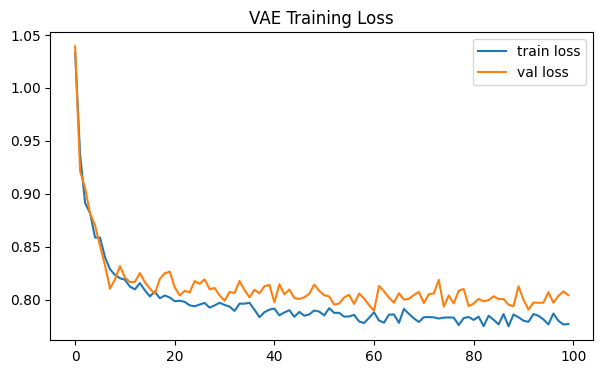

In [ ]:
# =========================
# TRAIN
# =========================
history = vae_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('VAE Training Loss')
plt.legend()
plt.show()
#vae.save(f"{BASE_DIR}/easy.keras")

In [ ]:
# =========================
# Get latent mu for clustering / evaluation
# =========================
# Use the inner vae (functional) model - this is the easiest and most reliable way

vae_model = tf.keras.models.load_model(f"{BASE_DIR}/easy.keras", custom_objects={'sampling': sampling})
_, Z_mu, _ = vae_model.predict(Xz, batch_size=32, verbose=0)

K = 12

kmeans_latent = KMeans(n_clusters=K, n_init=10, random_state=SEED)
labels_latent = kmeans_latent.fit_predict(Z_mu)

sil_latent = silhouette_score(Z_mu, labels_latent)
ch_latent  = calinski_harabasz_score(Z_mu, labels_latent)

print("VAE (latent mu) + KMeans")
print(" Silhouette:", round(sil_latent, 4))
print(" Calinski-Harabasz:", round(ch_latent, 2))

VAE (latent mu) + KMeans
 Silhouette: 0.3464
 Calinski-Harabasz: 1363.74



--- UMAP (PCA Baseline) ---


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP PCA Baseline latent space (Z_umap_pca_baseline) shape: (2209, 2)
UMAP PCA Baseline latent space (Z_umap_pca_baseline) min: -1.5106, max: 12.3057


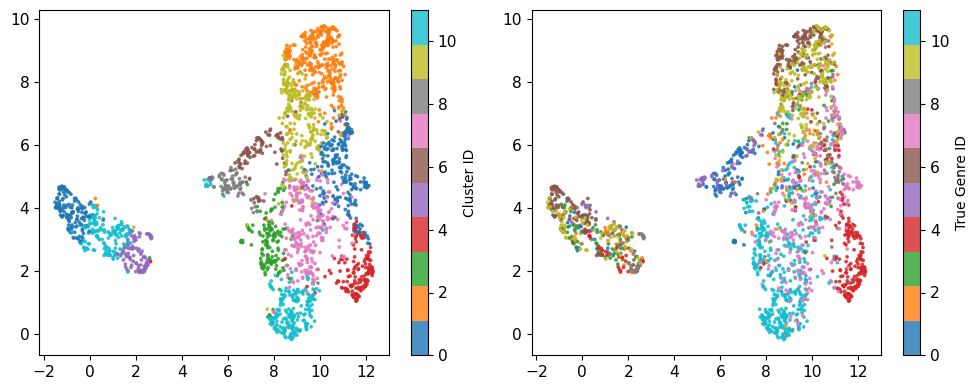


--- UMAP (Latent + KMeans) ---


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP latent space (Z_umap) shape: (2209, 2)
UMAP latent space (Z_umap) min: -4.5842, max: 15.0896


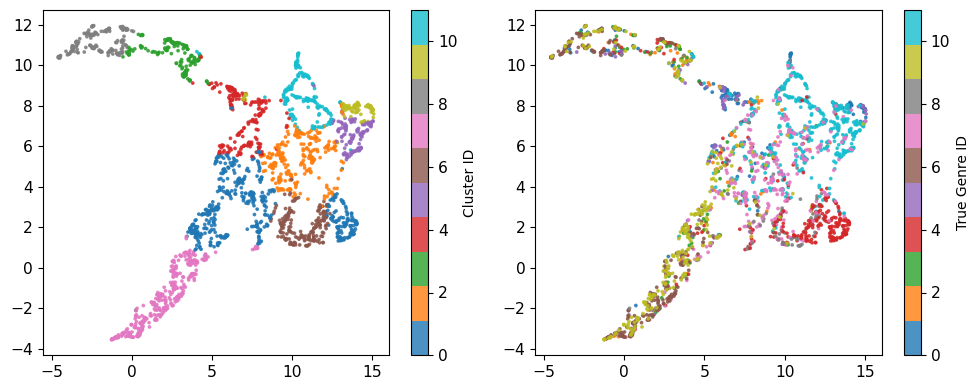

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap.umap_ as umap
import pandas as pd
import numpy as np

POINT_SIZE = 3
ALPHA = 0.8
FONT_SIZE = 14

# Prepare true labels once for all plots
true_labels, _ = pd.factorize(genres)

# =========================
# UMAP (PCA Baseline)
# =========================
print("\n--- UMAP (PCA Baseline) ---")
umap_model_pca_baseline = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Z_umap_pca_baseline = umap_model_pca_baseline.fit_transform(Xp)

# Print statements for UMAP PCA baseline
print(f"UMAP PCA Baseline latent space (Z_umap_pca_baseline) shape: {Z_umap_pca_baseline.shape}")
print(f"UMAP PCA Baseline latent space (Z_umap_pca_baseline) min: {np.min(Z_umap_pca_baseline):.4f}, max: {np.max(Z_umap_pca_baseline):.4f}")

plt.figure(figsize=(10,4))

# Predicted
plt.subplot(1,2,1)
scatter = plt.scatter(Z_umap_pca_baseline[:, 0], Z_umap_pca_baseline[:, 1],
            c=labels_pca, s=POINT_SIZE, alpha=ALPHA, cmap='tab10')
plt.xticks(fontsize=FONT_SIZE * 0.8)
plt.yticks(fontsize=FONT_SIZE * 0.8)
cbar = plt.colorbar(scatter, label='Cluster ID')
cbar.ax.tick_params(labelsize=FONT_SIZE * 0.8)
plt.title("UMAP (PCA Baseline) Colored by Predicted Cluster", fontsize=FONT_SIZE * 0.9)

# True genre
plt.subplot(1,2,2)
scatter2 = plt.scatter(Z_umap_pca_baseline[:, 0], Z_umap_pca_baseline[:, 1],
            c=true_labels, s=POINT_SIZE, alpha=ALPHA, cmap='tab10')
plt.xticks(fontsize=FONT_SIZE * 0.8)
plt.yticks(fontsize=FONT_SIZE * 0.8)
cbar2 = plt.colorbar(scatter2, label='True Genre ID')
cbar2.ax.tick_params(labelsize=FONT_SIZE * 0.8)
plt.title("UMAP (PCA Baseline) Colored by True Genre", fontsize=FONT_SIZE * 0.9)

plt.tight_layout()
plt.show()


# =========================
# UMAP (Latent + KMeans)
# =========================
print("\n--- UMAP (Latent + KMeans) ---")
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Z_umap = umap_model.fit_transform(Z_mu)

# Print statements for UMAP
print(f"UMAP latent space (Z_umap) shape: {Z_umap.shape}")
print(f"UMAP latent space (Z_umap) min: {np.min(Z_umap):.4f}, max: {np.max(Z_umap):.4f}")


plt.figure(figsize=(10,4))

# Predicted
plt.subplot(1,2,1)
scatter = plt.scatter(Z_umap[:, 0], Z_umap[:, 1],
            c=labels_latent, s=POINT_SIZE, alpha=ALPHA, cmap='tab10')
plt.xticks(fontsize=FONT_SIZE * 0.8)
plt.yticks(fontsize=FONT_SIZE * 0.8)
cbar = plt.colorbar(scatter, label='Cluster ID')
cbar.ax.tick_params(labelsize=FONT_SIZE * 0.8)
plt.title("UMAP (VAE Latent) Colored by Predicted Cluster", fontsize=FONT_SIZE * 0.9)


# True genre
plt.subplot(1,2,2)
scatter2 = plt.scatter(Z_umap[:, 0], Z_umap[:, 1],
            c=true_labels, s=POINT_SIZE, alpha=ALPHA, cmap='tab10')
plt.xticks(fontsize=FONT_SIZE * 0.8)
plt.yticks(fontsize=FONT_SIZE * 0.8)
cbar2 = plt.colorbar(scatter2, label='True Genre ID')
cbar2.ax.tick_params(labelsize=FONT_SIZE * 0.8)
plt.title("UMAP (VAE Latent) Colored by True Genre", fontsize=FONT_SIZE * 0.9)

plt.tight_layout()
plt.show()

# Medium

In [ ]:
ENCODER_NAME = "models/medium/encoder"
DECODER_NAME = "models/medium/decoder"
# ====================== ENCODER ======================
spec_inputs = layers.Input(shape=(128, 512, 1), name="spectrogram")
lyr_inputs = layers.Input(shape=(EMBED_DIM,), name="lyrics")


# ----- AUDIO PATH -----
x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(spec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

shape_before = keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
audio_encoded = layers.Dense(128, activation="relu")(x)
audio_encoded = L2NormalizeLayer()(audio_encoded)

# ----- LYRICS PATH -----
lyrics_encoded = layers.Dense(128, activation="relu")(lyr_inputs)
lyrics_encoded = layers.Dense(64, activation="relu")(lyrics_encoded)
lyrics_encoded = L2NormalizeLayer()(lyrics_encoded)

# ====================== FUSION ======================
lyrics_proj = layers.Dense(128)(lyrics_encoded)

gate_input_concat = layers.Concatenate()([audio_encoded, lyrics_proj])

gate_audio = layers.Dense(128, activation="relu")(gate_input_concat)
gate_audio = layers.Dense(128, activation="sigmoid", name="gate_audio")(gate_audio)
gate_lyrics = layers.Dense(128, activation="relu")(gate_input_concat)
gate_lyrics = layers.Dense(128, activation="sigmoid", name="gate_lyrics")(gate_lyrics)

fused = (gate_audio * audio_encoded) + \
        (gate_lyrics * lyrics_proj)

h = layers.Dense(128, activation="relu")(fused)

# ====================== LATENT ======================
mu = layers.Dense(LATENT_DIM, name="mu")(h)
logvar = layers.Dense(LATENT_DIM, name="logvar")(h)

z = Sampling()([mu, logvar])

encoder = keras.Model([spec_inputs, lyr_inputs], [mu, logvar, z], name="encoder")

# ====================== DECODER ======================
dec_input = layers.Input(shape=(LATENT_DIM,), name="z")

conditioned_latent = layers.Dense(LATENT_DIM + 64, activation="relu")(dec_input)
conditioned_latent = layers.Dense(LATENT_DIM + 32, activation="relu")(conditioned_latent)

# Audio reconstruction path
d = layers.Dense(shape_before[0] * shape_before[1] * shape_before[2], activation="relu")(conditioned_latent)
d = layers.Reshape(shape_before)(d)

d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(d)

audio_recon = layers.Conv2DTranspose(
    1, 3, padding="same", activation="sigmoid", name="audio_recon"
)(d)

if audio_recon.shape[2] > 512:
    audio_recon = layers.Cropping2D(((0, 0), (0, audio_recon.shape[2] - 512)))(audio_recon)

# Lyrics reconstruction path
d_lyrics = layers.Dense(64, activation="relu")(conditioned_latent)
lyrics_recon = layers.Dense(EMBED_DIM, activation="linear", name="lyrics_recon")(d_lyrics)

decoder = keras.Model(dec_input, [audio_recon, lyrics_recon], name="decoder")

# ====================== VAE ======================
@tf.keras.utils.register_keras_serializable()
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        spec, lyrics = inputs

        mu, logvar, z = self.encoder([spec, lyrics])
        recon_spec, recon_lyrics = self.decoder(z)

        # ======================
        # LOSSES
        # ======================

        audio_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(spec, recon_spec)
        )

        lyrics_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(lyrics - recon_lyrics), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar),
                axis=1
            )
        )

        total_loss = audio_loss + lyrics_loss + kl_loss
        self.add_loss(total_loss)

        return [recon_spec, recon_lyrics]

# ====================== BUILD ======================
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LR))

_ = vae([
    tf.zeros((1, 128, 512, 1)),
    tf.zeros((1, EMBED_DIM))
])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ====================== TRAINING ======================
cluster_cb = BestSilhouetteCallback(
    val_spec=Xz,
    val_lyrics=lyrics_all,
    true_labels_all=genres,
)

reduce_lr = ReduceLROnPlateau(
    monitor='silhouette',
    factor=0.5,
    patience=12,
    min_lr=1e-6,
    verbose=1,
    mode="max"
)

history = vae.fit(
    [X_train, lyrics_train],
    [X_train, lyrics_train],
    validation_data=([X_val, lyrics_val], [X_val, lyrics_val]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cluster_cb],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 30.4579z_for_clustering stats → mean=0.0260, std=0.1938
Epoch 1 | silhouette=0.4370 | ARI=0.0983 | Purity=0.2254 | clusters_found=12/12
✅ Saved models for Epoch 001 | Sil=0.4370, ARI=0.0983, Purity=0.2254
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 942ms/step - loss: 25.6569 - val_loss: 17.1791 - silhouette: 0.4370 - ari: 0.0983 - purity: 0.2254
Epoch 2/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 14.7245z_for_clustering stats → mean=0.0058, std=0.2688
Epoch 2 | silhouette=0.7109 | ARI=0.0204 | Purity=0.1720 | clusters_found=12/12
✅ Saved models for Epoch 002 | Sil=0.7109, ARI=0.0204, Purity=0.1720
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - loss: 13.7244 - val_loss: 12.4186 - silhouette: 0.7109 - ari: 0.0204 - purity: 0.1720
Epoch 3/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 12.0271z_for_clustering stats → mean=0.0124, std=0.2922
Epoch 3 | silhouette=0.7369 | ARI=0.0198 | Purity=0.1698 | clusters_found=12/12
✅ Saved models 

# Medium Only Audio

In [ ]:
ENCODER_NAME = "models/medium/encoder_aud"
DECODER_NAME = "models/medium/decoder_aud"
# ====================== ENCODER ======================
spec_inputs = layers.Input(shape=(128, 512, 1), name="spectrogram")

# ----- AUDIO PATH -----
x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(spec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

shape_before = keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
audio_encoded = layers.Dense(128, activation="relu")(x)
audio_encoded = L2NormalizeLayer()(audio_encoded)

# ====================== LATENT ======================
mu = layers.Dense(LATENT_DIM, name="mu")(audio_encoded)
logvar = layers.Dense(LATENT_DIM, name="logvar")(audio_encoded)

z = Sampling()([mu, logvar])

encoder = keras.Model(spec_inputs, [mu, logvar, z], name="encoder")

# ====================== DECODER ======================
dec_input = layers.Input(shape=(LATENT_DIM,), name="z")

conditioned_latent = layers.Dense(LATENT_DIM + 64, activation="relu")(dec_input)
conditioned_latent = layers.Dense(LATENT_DIM + 32, activation="relu")(conditioned_latent)

# Audio reconstruction path
d = layers.Dense(shape_before[0] * shape_before[1] * shape_before[2], activation="relu")(conditioned_latent)
d = layers.Reshape(shape_before)(d)

d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(d)

audio_recon = layers.Conv2DTranspose(
    1, 3, padding="same", activation="sigmoid", name="audio_recon"
)(d)

if audio_recon.shape[2] > 512:
    audio_recon = layers.Cropping2D(((0, 0), (0, audio_recon.shape[2] - 512)))(audio_recon)

decoder = keras.Model(dec_input, audio_recon, name="decoder")

# ====================== VAE ======================
@tf.keras.utils.register_keras_serializable()
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        spec = inputs

        mu, logvar, z = self.encoder(spec)
        recon_spec = self.decoder(z)

        # ======================
        # LOSSES
        # ======================

        # audio loss
        audio_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(spec, recon_spec)
        )

        # KL loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar),
                axis=1
            )
        )

        total_loss = audio_loss + kl_loss
        self.add_loss(total_loss)

        return recon_spec

# ====================== BUILD ======================
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LR))

_ = vae(
    tf.zeros((1, 128, 512, 1))
)

In [ ]:
cluster_cb = BestSilhouetteCallback(
    val_spec=Xz,
    val_lyrics=lyrics_all,
    true_labels_all=genres,
    is_audio_only = True
)

history = vae.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cluster_cb],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.7861z_for_clustering stats → mean=0.0013, std=0.0067
Epoch 1 | silhouette=0.2770 | ARI=0.0766 | Purity=0.2666 | clusters_found=12/12
✅ Saved models for Epoch 001 | Sil=0.2770, ARI=0.0766, Purity=0.2666
32/32 ━━━━━━━━━━━━━━━━━━━━ 187s 6s/step - loss: 0.7246 - val_loss: 0.6770 - silhouette: 0.2770 - ari: 0.0766 - purity: 0.2666
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.6750z_for_clustering stats → mean=0.0003, std=0.0014
Epoch 2 | silhouette=0.2238 | ARI=0.0709 | Purity=0.2626 | clusters_found=12/12
✅ Saved models for Epoch 002 | Sil=0.2238, ARI=0.0709, Purity=0.2626
32/32 ━━━━━━━━━━━━━━━━━━━━ 212s 6s/step - loss: 0.6733 - val_loss: 0.6670 - silhouette: 0.2238 - ari: 0.0709 - purity: 0.2626
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.6676z_for_clustering stats → mean=-0.0000, std=0.0004
Epoch 3 | silhouette=0.1137 | ARI=0.0513 | Purity=0.2327 | clusters_found=12/12
✅ Saved models for Epoch 003 | Si

KeyboardInterrupt: 

Loading 'audio + lyrics' VAE models...
 'audio + lyrics' VAE models loaded.
Loading 'audio only' VAE models...
 'audio only' VAE models loaded.

Extracting latent representations...
 Latent representations from 'audio + lyrics' VAE extracted.
 Latent representations from 'audio only' VAE extracted.

--- Clustering for Audio + Lyrics ---
  - K-Means (K=12)...
  - Agglomerative Clustering (K=12)...
  - DBSCAN...

Generating t-SNE and UMAP visualizations for Audio + Lyrics VAE Latent...
Computing t-SNE for: Audio + Lyrics VAE Latent


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


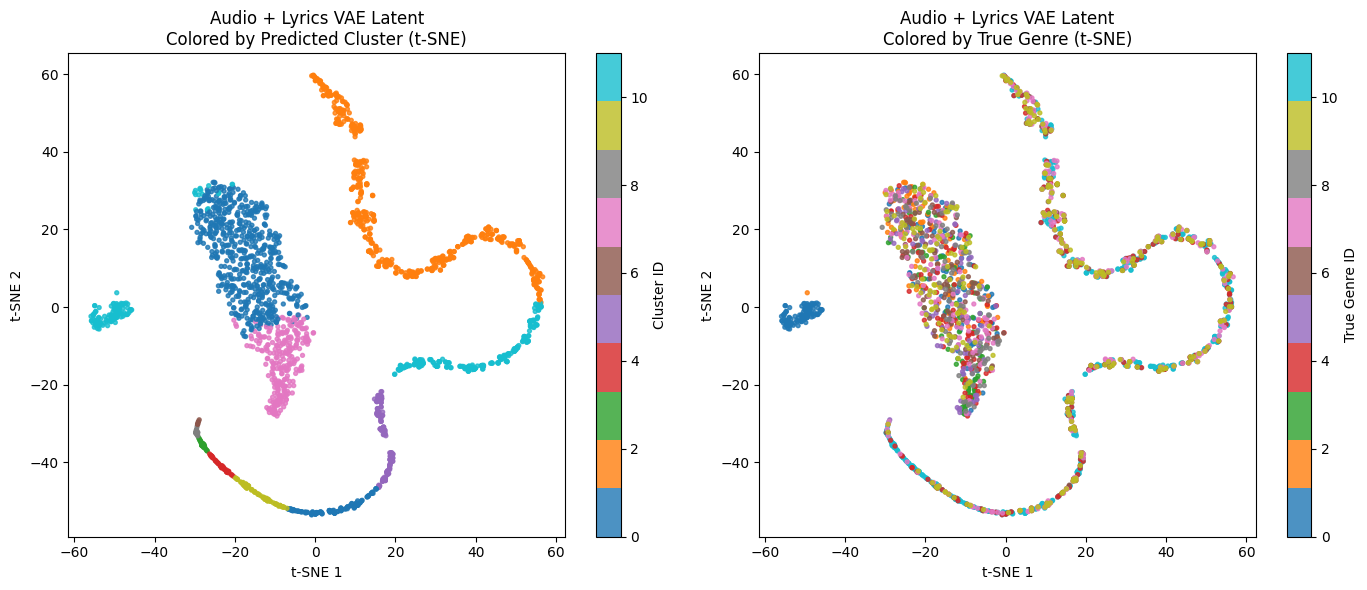

Computing UMAP for: Audio + Lyrics VAE Latent


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


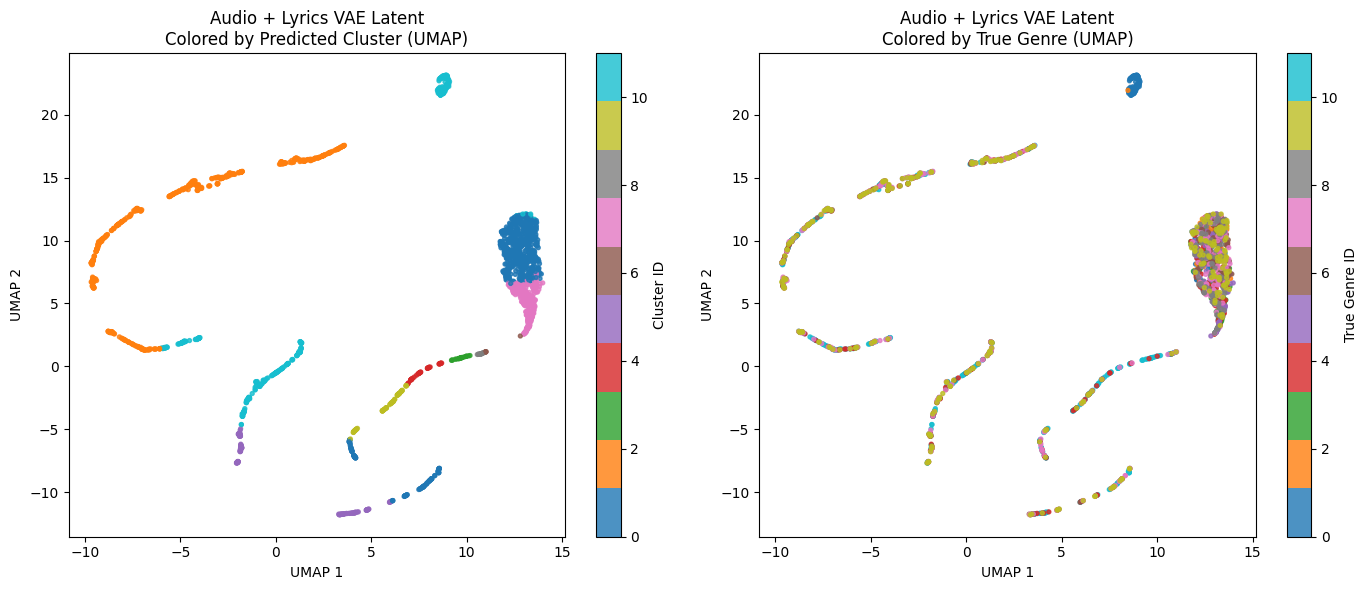


--- Clustering for Audio ---
  - K-Means (K=12)...
  - Agglomerative Clustering (K=12)...
  - DBSCAN...

Generating t-SNE and UMAP visualizations for Audio Only VAE Latent...
Computing t-SNE for: Audio Only VAE Latent


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


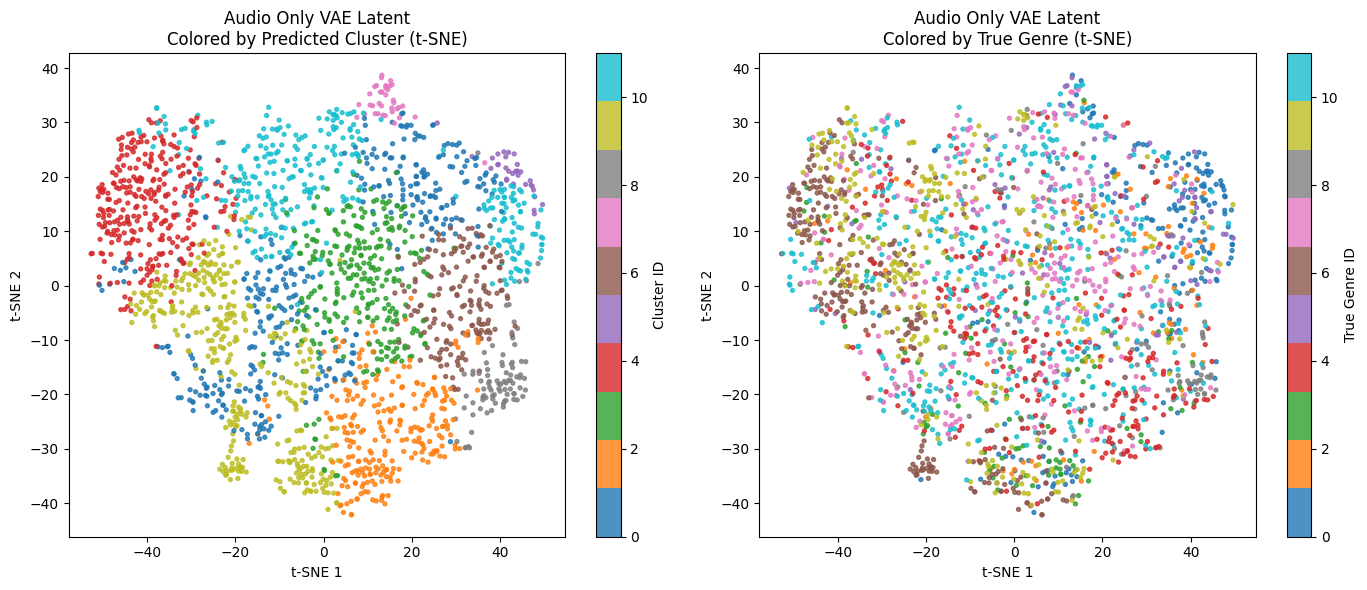

Computing UMAP for: Audio Only VAE Latent


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


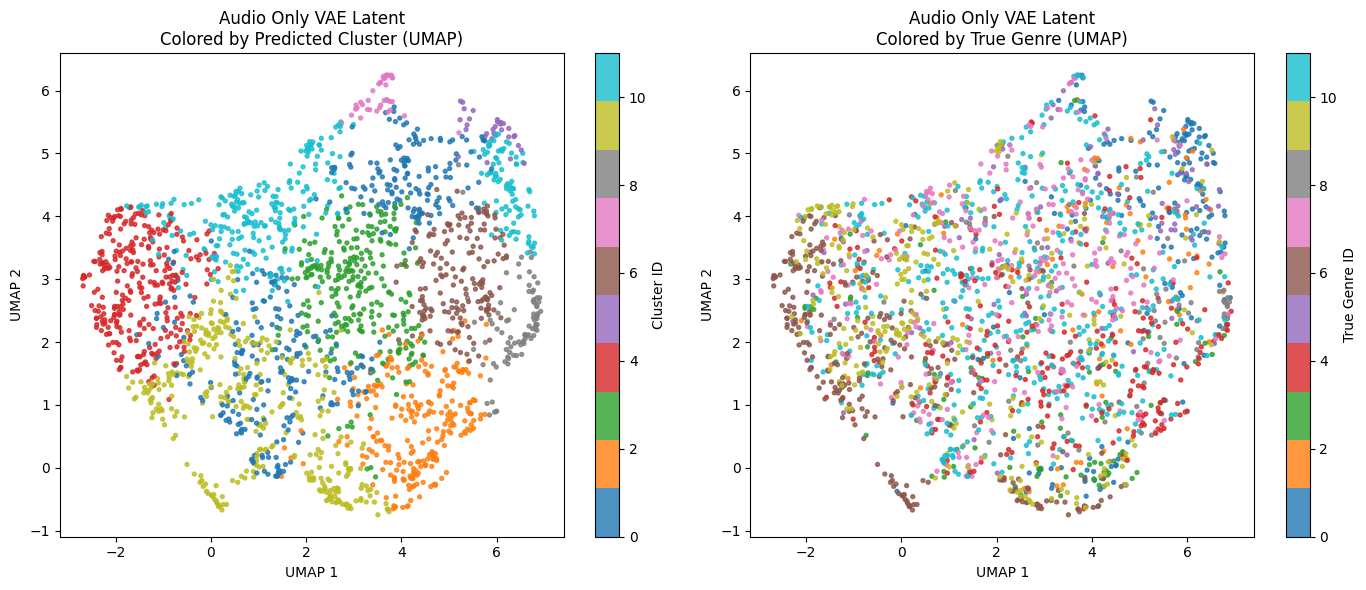


Clustering Algorithm Comparison
         Model                Algorithm  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI  Purity  Clusters Found
Audio + Lyrics                  K-Means      0.5371          0.5402      224265.500000 0.0724  0.2345              12
Audio + Lyrics Agglomerative Clustering      0.4884          0.5594      194091.046875 0.0488  0.1987              12
Audio + Lyrics         DBSCAN (eps=0.5)      0.9155          0.1116       66099.296875 0.0771  0.1521               2
         Audio                  K-Means      0.1121          1.7872         321.700012 0.0876  0.2938              12
         Audio Agglomerative Clustering      0.0538          1.9996         277.079987 0.0574  0.2576              12
         Audio         DBSCAN (eps=0.5)         NaN             NaN                NaN 0.0000  0.1340               1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import os
from sklearn.manifold import TSNE

try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

# --- 1. Load Models ---

print("Loading 'audio + lyrics' VAE models...")
audio_lyrics_encoder_path = os.path.join(BASE_DIR, "models/medium/encoder_epoch_005.keras")
audio_lyrics_decoder_path = os.path.join(BASE_DIR, "models/medium/decoder_epoch_005.keras")

custom_objects_common = {
    'Sampling': Sampling,
    'L2NormalizeLayer': L2NormalizeLayer,
    'LogVarClip': LogVarClip
}

try:
    audio_lyrics_encoder = tf.keras.models.load_model(audio_lyrics_encoder_path, custom_objects=custom_objects_common)
    audio_lyrics_decoder = tf.keras.models.load_model(audio_lyrics_decoder_path, custom_objects=custom_objects_common)
    print(" 'audio + lyrics' VAE models loaded.")
except Exception as e:
    print(f"Error loading 'audio + lyrics' VAE models: {e}")
    audio_lyrics_encoder = None
    audio_lyrics_decoder = None

print("Loading 'audio only' VAE models...")
audio_only_encoder_path = os.path.join(BASE_DIR, "models/medium/encoder_aud_epoch_004.keras")
audio_only_decoder_path = os.path.join(BASE_DIR, "models/medium/decoder_aud_epoch_004.keras")

try:
    audio_only_encoder = tf.keras.models.load_model(audio_only_encoder_path, custom_objects=custom_objects_common)
    audio_only_decoder = tf.keras.models.load_model(audio_only_decoder_path, custom_objects=custom_objects_common)
    print(" 'audio only' VAE models loaded.")
except Exception as e:
    print(f"Error loading 'audio only' VAE models: {e}")
    audio_only_encoder = None
    audio_only_decoder = None


# --- 2. Extract Latent Representations ---
print("\nExtracting latent representations...")
z_audio_lyrics = None
if audio_lyrics_encoder:
    mu_audio_lyrics, _, _ = audio_lyrics_encoder.predict([Xz, lyrics_all], batch_size=BATCH_SIZE, verbose=0)
    z_audio_lyrics = mu_audio_lyrics
    print(" Latent representations from 'audio + lyrics' VAE extracted.")

z_audio_only = None
if audio_only_encoder:
    mu_audio_only, _, _ = audio_only_encoder.predict(Xz, batch_size=BATCH_SIZE, verbose=0)
    z_audio_only = mu_audio_only
    print(" Latent representations from 'audio only' VAE extracted.")


# --- 3. Define Clustering and Evaluation Function ---
def evaluate_clustering(features, true_labels, model_type_name, n_clusters=12):
    results = []

    if features is None:
        print(f"Skipping clustering for {model_type_name} due to missing features.")
        return results

    print(f"\n--- Clustering for {model_type_name} ---")

    # K-Means
    print(f"  - K-Means (K={n_clusters})...")
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=SEED)
    labels_kmeans = kmeans.fit_predict(features)
    n_found_kmeans = len(np.unique(labels_kmeans))
    if n_found_kmeans >= 2:
        results.append({
            "Model": model_type_name,
            "Algorithm": "K-Means",
            "Silhouette": round(silhouette_score(features, labels_kmeans), 4),
            "Davies-Bouldin": round(davies_bouldin_score(features, labels_kmeans), 4),
            "Calinski-Harabasz": round(calinski_harabasz_score(features, labels_kmeans), 2),
            "ARI": round(adjusted_rand_score(true_labels, labels_kmeans), 4),
            "Purity": round(cluster_purity(true_labels, labels_kmeans), 4),
            "Clusters Found": n_found_kmeans
        })
    else:
        results.append({
            "Model": model_type_name,
            "Algorithm": "K-Means",
            "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
            "ARI": round(adjusted_rand_score(true_labels, labels_kmeans), 4),
            "Purity": round(cluster_purity(true_labels, labels_kmeans), 4),
            "Clusters Found": n_found_kmeans
        })


    # Agglomerative Clustering
    print(f"  - Agglomerative Clustering (K={n_clusters})...")
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels_agg = agg_clustering.fit_predict(features)
    n_found_agg = len(np.unique(labels_agg))
    if n_found_agg >= 2:
        results.append({
            "Model": model_type_name,
            "Algorithm": "Agglomerative Clustering",
            "Silhouette": round(silhouette_score(features, labels_agg), 4),
            "Davies-Bouldin": round(davies_bouldin_score(features, labels_agg), 4),
            "Calinski-Harabasz": round(calinski_harabasz_score(features, labels_agg), 2),
            "ARI": round(adjusted_rand_score(true_labels, labels_agg), 4),
            "Purity": round(cluster_purity(true_labels, labels_agg), 4),
            "Clusters Found": n_found_agg
        })
    else:
        results.append({
            "Model": model_type_name,
            "Algorithm": "Agglomerative Clustering",
            "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
            "ARI": round(adjusted_rand_score(true_labels, labels_agg), 4),
            "Purity": round(cluster_purity(true_labels, labels_agg), 4),
            "Clusters Found": n_found_agg
        })


    # DBSCAN
    print(f"  - DBSCAN...")

    eps_dbscan = 0.5
    min_samples_dbscan = 2 * LATENT_DIM

    dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
    labels_dbscan = dbscan.fit_predict(features)
    n_found_dbscan = len(np.unique(labels_dbscan))

    if -1 in labels_dbscan:
        actual_clusters = np.unique(labels_dbscan[labels_dbscan != -1])
        n_found_dbscan = len(actual_clusters)
        non_noise_mask = labels_dbscan != -1

        if np.sum(non_noise_mask) > 0 and n_found_dbscan >= 2:
            results.append({
                "Model": model_type_name,
                "Algorithm": f"DBSCAN (eps={eps_dbscan})",
                "Silhouette": round(silhouette_score(features[non_noise_mask], labels_dbscan[non_noise_mask]), 4),
                "Davies-Bouldin": round(davies_bouldin_score(features[non_noise_mask], labels_dbscan[non_noise_mask]), 4),
                "Calinski-Harabasz": round(calinski_harabasz_score(features[non_noise_mask], labels_dbscan[non_noise_mask]), 2),
                "ARI": round(adjusted_rand_score(true_labels[non_noise_mask], labels_dbscan[non_noise_mask]), 4),
                "Purity": round(cluster_purity(true_labels[non_noise_mask], labels_dbscan[non_noise_mask]), 4),
                "Clusters Found": n_found_dbscan
            })
        else:
             results.append({
                "Model": model_type_name,
                "Algorithm": f"DBSCAN (eps={eps_dbscan})",
                "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
                "ARI": round(adjusted_rand_score(true_labels[non_noise_mask], labels_dbscan[non_noise_mask]), 4) if np.sum(non_noise_mask) > 0 else np.nan,
                "Purity": round(cluster_purity(true_labels[non_noise_mask], labels_dbscan[non_noise_mask]), 4) if np.sum(non_noise_mask) > 0 else np.nan,
                "Clusters Found": n_found_dbscan
            })
    else:
        if n_found_dbscan >= 2:
            results.append({
                "Model": model_type_name,
                "Algorithm": f"DBSCAN (eps={eps_dbscan})",
                "Silhouette": round(silhouette_score(features, labels_dbscan), 4),
                "Davies-Bouldin": round(davies_bouldin_score(features, labels_dbscan), 4),
                "Calinski-Harabasz": round(calinski_harabasz_score(features, labels_dbscan), 2),
                "ARI": round(adjusted_rand_score(true_labels, labels_dbscan), 4),
                "Purity": round(cluster_purity(true_labels, labels_dbscan), 4),
                "Clusters Found": n_found_dbscan
            })
        else:
            results.append({
                "Model": model_type_name,
                "Algorithm": f"DBSCAN (eps={eps_dbscan})",
                "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
                "ARI": round(adjusted_rand_score(true_labels, labels_dbscan), 4),
                "Purity": round(cluster_purity(true_labels, labels_dbscan), 4),
                "Clusters Found": n_found_dbscan
            })

    return results

def plot_embedding(X, labels, title, true_genres=None, method="t-SNE"):
    print(f"Computing {method} for: {title}")

    if method == "t-SNE":
        reducer = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
    else:
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)

    X_emb = reducer.fit_transform(X)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap='tab10', s=8, alpha=0.8)
    plt.title(f"{title}\nColored by Predicted Cluster ({method})")
    plt.colorbar(scatter, label='Cluster ID')
    plt.xlabel(f'{method} 1')
    plt.ylabel(f'{method} 2')

    if true_genres is not None:
        plt.subplot(1, 2, 2)
        numerical_true_genres, _ = pd.factorize(true_genres)
        scatter2 = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=numerical_true_genres, cmap='tab10', s=8, alpha=0.8)
        plt.title(f"{title}\nColored by True Genre ({method})")
        plt.colorbar(scatter2, label='True Genre ID')
        plt.xlabel(f'{method} 1')
        plt.ylabel(f'{method} 2')

    plt.tight_layout()
    plt.show()

# --- 4. Perform Clustering and Evaluation ---
all_results = []
n_clusters_for_plot = 12

if z_audio_lyrics is not None:
    all_results.extend(evaluate_clustering(z_audio_lyrics, genres, "Audio + Lyrics"))
    kmeans_audio_lyrics = KMeans(n_clusters=n_clusters_for_plot, n_init=10, random_state=SEED)
    labels_audio_lyrics = kmeans_audio_lyrics.fit_predict(z_audio_lyrics)
    print("\nGenerating t-SNE and UMAP visualizations for Audio + Lyrics VAE Latent...")
    plot_embedding(z_audio_lyrics, labels_audio_lyrics, "Audio + Lyrics VAE Latent", true_genres=genres, method="t-SNE")
    if UMAP_AVAILABLE:
        plot_embedding(z_audio_lyrics, labels_audio_lyrics, "Audio + Lyrics VAE Latent", true_genres=genres, method="UMAP")


if z_audio_only is not None:
    all_results.extend(evaluate_clustering(z_audio_only, genres, "Audio"))
    kmeans_audio_only = KMeans(n_clusters=n_clusters_for_plot, n_init=10, random_state=SEED)
    labels_audio_only = kmeans_audio_only.fit_predict(z_audio_only)
    print("\nGenerating t-SNE and UMAP visualizations for Audio Only VAE Latent...")
    plot_embedding(z_audio_only, labels_audio_only, "Audio Only VAE Latent", true_genres=genres, method="t-SNE")
    if UMAP_AVAILABLE:
        plot_embedding(z_audio_only, labels_audio_only, "Audio Only VAE Latent", true_genres=genres, method="UMAP")

# --- 5. Present Results ---
df_comparison = pd.DataFrame(all_results)

print("\n" + "="*90)
print("Clustering Algorithm Comparison")
print("="*90)
print(df_comparison.to_string(index=False))
print("="*90)


Loading and extracting latents for medium models...
Latents ready.

=== FINAL RESULTS (Medium Models) ===
                               Method  Silhouette        DB             CH  \
0         Audio + Lyrics VAE + KMeans    0.537124  0.540203  224265.500000   
1  Audio + Lyrics VAE + Agglomerative    0.488403  0.559386  194091.031250   
2         Audio + Lyrics VAE + DBSCAN    0.911663  0.115057   60331.476562   
3             Audio Only VAE + KMeans    0.112050  1.787240     321.696716   
4      Audio Only VAE + Agglomerative    0.053807  1.999622     277.080841   
5             Audio Only VAE + DBSCAN         NaN       NaN            NaN   

        NMI       ARI    Purity  
0  0.243208  0.072358  0.234495  
1  0.192907  0.048772  0.198732  
2  0.228025  0.076762  0.152105  
3  0.161326  0.087622  0.293798  
4  0.130808  0.057357  0.257583  
5       NaN       NaN       NaN  

Generating plots for medium models...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Showing: Audio + Lyrics VAE + KMeans | t-SNE


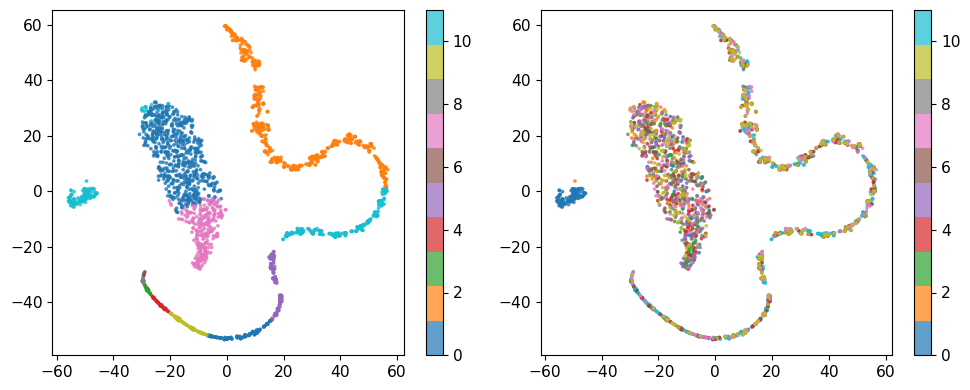

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: Audio + Lyrics VAE + KMeans | UMAP


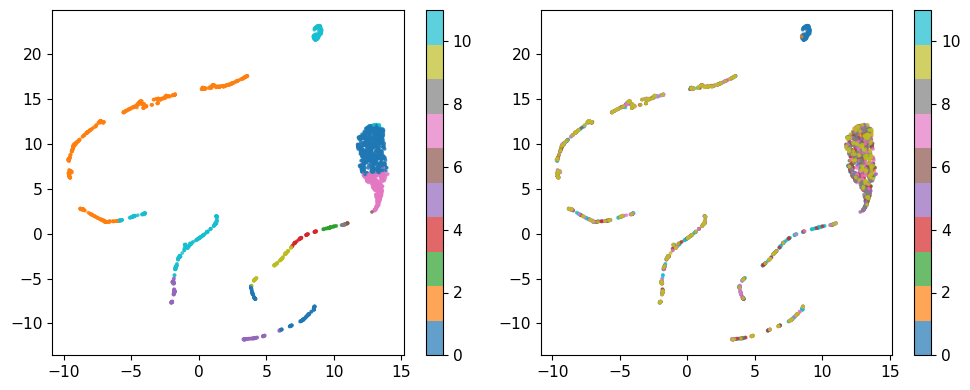

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Showing: Audio Only VAE + KMeans | t-SNE


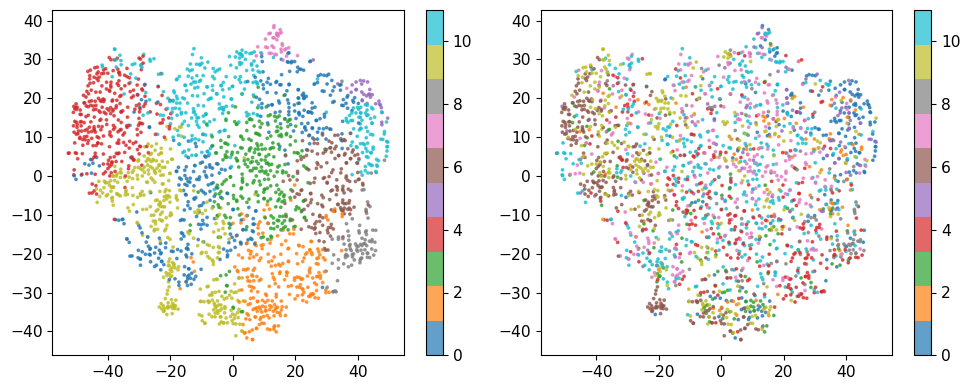

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: Audio Only VAE + KMeans | UMAP


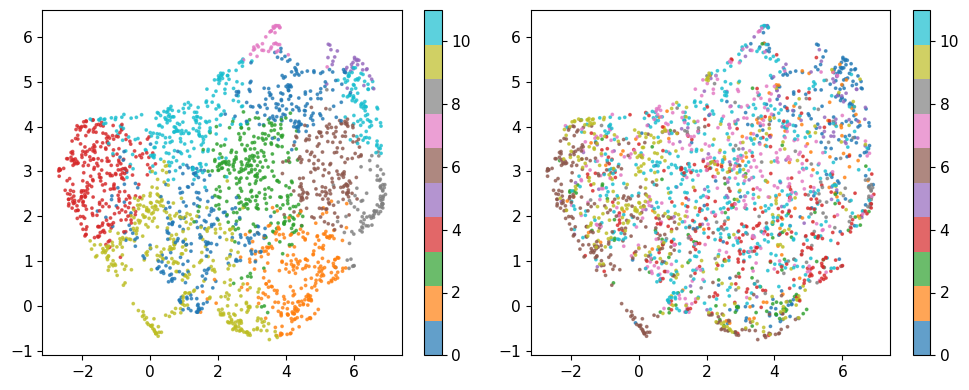


Done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, calinski_harabasz_score,
    normalized_mutual_info_score
)
from sklearn.manifold import TSNE

# UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

import tensorflow as tf
import tensorflow.keras as keras

# ====================== LOAD MODELS AND EXTRACT LATENTS ======================
print("Loading and extracting latents for medium models...")

# Ensure these variables are populated from previous cells
if 'z_audio_lyrics' not in globals() or z_audio_lyrics is None:
    print("z_audio_lyrics not found or is None. Please ensure cell A2YxOb_zUsfp has been run.")
if 'z_audio_only' not in globals() or z_audio_only is None:
    print("z_audio_only not found or is None. Please ensure cell A2YxOb_zUsfp has been run.")

print("Latents ready.")

# ====================== CLUSTERING ======================
def run_clustering(X):
    results = {}

    results["KMeans"] = KMeans(n_clusters=12, random_state=42, n_init=10).fit_predict(X)
    results["Agglomerative"] = AgglomerativeClustering(n_clusters=12).fit_predict(X)

    min_samples_dbscan = max(2, int(0.01 * X.shape[0]))
    if X.shape[0] > min_samples_dbscan:
        dbscan_labels = DBSCAN(eps=0.5, min_samples=min_samples_dbscan).fit_predict(X)
        if len(np.unique(dbscan_labels)) < 2 or (len(np.unique(dbscan_labels)) == 2 and -1 in np.unique(dbscan_labels)):
             results["DBSCAN"] = np.full(X.shape[0], -1)
        else:
            results["DBSCAN"] = dbscan_labels
    else:
        results["DBSCAN"] = np.full(X.shape[0], -1)

    return results

# ====================== METRICS ======================
def get_metrics(features, labels, name):
    if "DBSCAN" in name and -1 in labels:
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 0 and len(np.unique(labels[non_noise_mask])) > 1:
            filtered_features = features[non_noise_mask]
            filtered_labels = labels[non_noise_mask]
            silhouette = silhouette_score(filtered_features, filtered_labels)
            db_score = davies_bouldin_score(filtered_features, filtered_labels)
            ch_score = calinski_harabasz_score(filtered_features, filtered_labels)
            nmi_score = normalized_mutual_info_score(genres[non_noise_mask], filtered_labels)
            ari_score = adjusted_rand_score(genres[non_noise_mask], filtered_labels)
            purity_score = cluster_purity(genres[non_noise_mask], filtered_labels)
        else:
            silhouette, db_score, ch_score = np.nan, np.nan, np.nan
            nmi_score = normalized_mutual_info_score(genres[non_noise_mask], labels[non_noise_mask]) if np.sum(non_noise_mask) > 0 else np.nan
            ari_score = adjusted_rand_score(genres[non_noise_mask], labels[non_noise_mask]) if np.sum(non_noise_mask) > 0 else np.nan
            purity_score = cluster_purity(genres[non_noise_mask], labels[non_noise_mask]) if np.sum(non_noise_mask) > 0 else np.nan

    elif len(np.unique(labels)) < 2:
        silhouette, db_score, ch_score = np.nan, np.nan, np.nan
        nmi_score = normalized_mutual_info_score(genres, labels)
        ari_score = adjusted_rand_score(genres, labels)
        purity_score = cluster_purity(genres, labels)

    else:
        silhouette = silhouette_score(features, labels)
        db_score = davies_bouldin_score(features, labels)
        ch_score = calinski_harabasz_score(features, labels)
        nmi_score = normalized_mutual_info_score(genres, labels)
        ari_score = adjusted_rand_score(genres, labels)
        purity_score = cluster_purity(genres, labels)

    return {
        "Method": name,
        "Silhouette": silhouette,
        "DB": db_score,
        "CH": ch_score,
        "NMI": nmi_score,
        "ARI": ari_score,
        "Purity": purity_score
    }

# ====================== EVALUATION ======================
results = []

methods = {
    "Audio + Lyrics VAE": z_audio_lyrics,
    "Audio Only VAE": z_audio_only
}

cluster_results = {}

for name, X in methods.items():
    if X is None:
        print(f"Skipping evaluation for '{name}' as latent features are not available.")
        continue

    cluster_outputs = run_clustering(X)
    cluster_results[name] = cluster_outputs

    for algo, labels in cluster_outputs.items():
        results.append(get_metrics(X, labels, f"{name} + {algo}"))

df = pd.DataFrame(results)
print("\n=== FINAL RESULTS (Medium Models) ===")
print(df)

# ====================== CLEAN PLOTTING ======================
def plot_embedding(X, labels, true_genres, title, method="t-SNE"):
    if X is None or len(X) == 0:
        print(f"Skipping plotting for {title} ({method}) due to no data.")
        return

    if "DBSCAN" in title and -1 in labels:
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) > 0 and len(np.unique(labels[non_noise_mask])) > 1:
            X_filtered = X[non_noise_mask]
            labels_filtered = labels[non_noise_mask]
            true_genres_filtered = true_genres[non_noise_mask]
        else:
            print(f"Skipping plotting for {title} ({method}) as only noise or single cluster found.")
            return
    else:
        X_filtered = X
        labels_filtered = labels
        true_genres_filtered = true_genres

    if method == "t-SNE":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    else:
        print(f"Unknown reduction method: {method}")
        return

    X_emb = reducer.fit_transform(X_filtered)

    POINT_SIZE = 3
    FONT_SIZE = 14

    print(f"\nShowing: {title} | {method}")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=labels_filtered, cmap='tab10',
        s=POINT_SIZE, alpha=0.7
    )
    cbar = plt.colorbar(scatter)
    cbar.ax.tick_params(labelsize=FONT_SIZE * 0.8)
    plt.xticks(fontsize=FONT_SIZE * 0.8)
    plt.yticks(fontsize=FONT_SIZE * 0.8)

    plt.subplot(1, 2, 2)
    y_true, _ = pd.factorize(true_genres_filtered)

    scatter2 = plt.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=y_true, cmap='tab10',
        s=POINT_SIZE, alpha=0.7
    )
    cbar2 = plt.colorbar(scatter2)
    cbar2.ax.tick_params(labelsize=FONT_SIZE * 0.8)

    plt.xticks(fontsize=FONT_SIZE * 0.8)
    plt.yticks(fontsize=FONT_SIZE * 0.8)

    plt.tight_layout()
    plt.show()

# ====================== VISUALIZE ======================
print("\nGenerating plots for medium models...")

for name, X in methods.items():
    if X is None:
        continue

    algo = "KMeans"
    labels = cluster_results[name][algo]

    plot_embedding(X, labels, genres, f"{name} + {algo}", method="t-SNE")

    if UMAP_AVAILABLE:
        plot_embedding(X, labels, genres, f"{name} + {algo}", method="UMAP")


print("\nDone.")

# HARD

In [ ]:
ENCODER_NAME = "models/hard/encoder_CVAE"
DECODER_NAME = "models/hard/decoder_CVAE"

# ====================== ENCODER ======================
spec_inputs = layers.Input(shape=(128, 512, 1), name="spectrogram")
lyr_inputs = layers.Input(shape=(EMBED_DIM,), name="lyrics")
genre_inputs = layers.Input(shape=(GENRE_DIM,), name="genre_input")

# ----- AUDIO PATH -----
x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(spec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

shape_before = keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
audio_encoded = layers.Dense(128, activation="relu")(x)
audio_encoded = L2NormalizeLayer()(audio_encoded)

# ----- LYRICS PATH (STRENGTHENED for better ARI) -----
lyrics_encoded = layers.Dense(128, activation="relu")(lyr_inputs)
lyrics_encoded = layers.Dense(64, activation="relu")(lyrics_encoded)
lyrics_encoded = L2NormalizeLayer()(lyrics_encoded)

# ====================== GENRE CONDITIONING (EARLY) ======================
genre_dense_enc = layers.Dense(64, activation="relu", name="genre_dense_encoder")(genre_inputs)
genre_proj_for_fusion = layers.Dense(128, activation="relu", name="genre_proj_for_fusion")(genre_dense_enc)

# ====================== FUSION (GATED FUSION with early genre conditioning and full lyrics) ======================
lyrics_proj = layers.Dense(128)(lyrics_encoded)

gate_input_concat = layers.Concatenate()([audio_encoded, lyrics_proj, genre_proj_for_fusion])

gate_audio = layers.Dense(128, activation="relu")(gate_input_concat)
gate_audio = layers.Dense(128, activation="sigmoid", name="gate_audio")(gate_audio)
gate_lyrics = layers.Dense(128, activation="relu")(gate_input_concat)
gate_lyrics = layers.Dense(128, activation="sigmoid", name="gate_lyrics")(gate_lyrics)
gate_genre = layers.Dense(128, activation="relu")(gate_input_concat)
gate_genre = layers.Dense(128, activation="sigmoid", name="gate_genre")(gate_genre)

fused = (gate_audio * audio_encoded) + \
        (gate_lyrics * lyrics_proj) + \
        (gate_genre * genre_proj_for_fusion)

h = layers.Dense(128, activation="relu")(fused)

# ====================== LATENT ======================
mu = layers.Dense(LATENT_DIM, name="mu")(h)
logvar = layers.Dense(LATENT_DIM, name="logvar")(h)

z = Sampling()([mu, logvar])

encoder = keras.Model([spec_inputs, lyr_inputs, genre_inputs], [mu, logvar, z], name="encoder")

# ====================== DECODER ======================
dec_input = layers.Input(shape=(LATENT_DIM,), name="z")
genre_conditioning_input = layers.Input(shape=(GENRE_DIM,), name="genre_conditioning_input")

conditioned_latent = layers.Concatenate()([dec_input, genre_cond_dense_dec])
genre_cond_dense_dec = layers.Dense(64, activation="relu", name="genre_dense_decoder")(genre_conditioning_input)
conditioned_latent = layers.Dense(LATENT_DIM + 64, activation="relu")(conditioned_latent)
conditioned_latent = layers.Dense(LATENT_DIM + 32, activation="relu")(conditioned_latent)

d = layers.Dense(shape_before[0] * shape_before[1] * shape_before[2], activation="relu")(conditioned_latent)
d = layers.Reshape(shape_before)(d)

d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(d)

audio_recon = layers.Conv2DTranspose(
    1, 3, padding="same", activation="sigmoid", name="audio_recon"
)(d)


if audio_recon.shape[2] > 512:
    audio_recon = layers.Cropping2D(((0, 0), (0, audio_recon.shape[2] - 512)))(audio_recon)

d_lyrics = layers.Dense(64, activation="relu")(conditioned_latent)
lyrics_recon = layers.Dense(EMBED_DIM, activation="linear", name="lyrics_recon")(d_lyrics)

decoder = keras.Model([dec_input, genre_conditioning_input], [audio_recon, lyrics_recon], name="decoder")

# ====================== VAE ======================
@tf.keras.utils.register_keras_serializable()
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        spec, lyrics, genres = inputs

        mu, logvar, z = self.encoder([spec, lyrics, genres])
        recon_spec, recon_lyrics = self.decoder([z, genres])

        # ======================
        # LOSSES
        # ======================

        audio_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(spec, recon_spec)
        )

        lyrics_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(lyrics - recon_lyrics), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar),
                axis=1
            )
        )

        total_loss = audio_loss + lyrics_loss + kl_loss
        self.add_loss(total_loss)

        return [recon_spec, recon_lyrics]

# ====================== BUILD ======================
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LR))

_ = vae([
    tf.zeros((1, 128, 512, 1)),
    tf.zeros((1, EMBED_DIM)),
    tf.zeros((1, GENRE_DIM))
])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

cluster_cb = BestSilhouetteCallback(
    val_spec=Xz,
    val_lyrics=lyrics_all,
    true_labels_all=genres,
    is_conditional_model = True
)

reduce_lr = ReduceLROnPlateau(
    monitor='silhouette',
    factor=0.5,
    patience=12,
    min_lr=1e-6,
    verbose=1,
    mode="max"
)

history = vae.fit(
    [X_train, lyrics_train, genres_train_encoded],
    [X_train, lyrics_train],
    validation_data=([X_val, lyrics_val, genres_val_encoded], [X_val, lyrics_val]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cluster_cb],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.1437z_for_clustering stats → mean=0.0002, std=0.0043
Epoch 1 | silhouette=0.2328 | ARI=0.4901 | Purity=0.6523 | clusters_found=12/12
✅ Saved models for Epoch 001 | Sil=0.2328, ARI=0.4901, Purity=0.6523
32/32 ━━━━━━━━━━━━━━━━━━━━ 198s 6s/step - loss: 0.1079 - val_loss: 0.0741 - silhouette: 0.2328 - ari: 0.4901 - purity: 0.6523
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.0672z_for_clustering stats → mean=-0.0001, std=0.0011
Epoch 2 | silhouette=0.2962 | ARI=0.1004 | Purity=0.2680 | clusters_found=12/12
✅ Saved models for Epoch 002 | Sil=0.2962, ARI=0.1004, Purity=0.2680
32/32 ━━━━━━━━━━━━━━━━━━━━ 181s 6s/step - loss: 0.0660 - val_loss: 0.0668 - silhouette: 0.2962 - ari: 0.1004 - purity: 0.2680
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.0612z_for_clustering stats → mean=0.0000, std=0.0007
Epoch 3 | silhouette=0.4043 | ARI=0.0565 | Purity=0.2096 | clusters_found=12/12
✅ Saved models for Epoch 003 | Si

KeyboardInterrupt: 

# HARD Beta

In [ ]:
ENCODER_NAME = "encoder_BetaVAE"
DECODER_NAME = "decoder_BetaVAE"

@tf.keras.utils.register_keras_serializable()
class KLAnnealer(tf.keras.callbacks.Callback):
    def __init__(self, target_beta, warmup_epochs, start_epoch=0, **kwargs):
        super().__init__(**kwargs)
        self.target_beta = target_beta
        self.warmup_epochs = warmup_epochs
        self.start_epoch = start_epoch

    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'kl_weight'):
            if epoch < self.start_epoch:
                current_beta = 0.0
            elif epoch < self.start_epoch + self.warmup_epochs:
                ratio = (epoch - self.start_epoch) / self.warmup_epochs
                current_beta = self.target_beta * ratio
            else:
                current_beta = self.target_beta
            tf.keras.backend.set_value(self.model.kl_weight, current_beta)
            print(f"Epoch {epoch+1}: KL weight (beta) set to {current_beta:.6f}")
        else:
            print("Warning: VAE model does not have 'kl_weight' attribute.")

    def get_config(self):
        config = super().get_config()
        config.update({
            "target_beta": self.target_beta,
            "warmup_epochs": self.warmup_epochs,
            "start_epoch": self.start_epoch,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

spec_inputs = layers.Input(shape=(128, 512, 1), name="spectrogram")
lyr_inputs = layers.Input(shape=(EMBED_DIM,), name="lyrics")

x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(spec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

shape_before = keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
audio_encoded = layers.Dense(128, activation="relu")(x)
audio_encoded = L2NormalizeLayer()(audio_encoded)

lyrics_encoded = layers.Dense(128, activation="relu")(lyr_inputs)
lyrics_encoded = layers.Dense(64, activation="relu")(lyrics_encoded)
lyrics_encoded = L2NormalizeLayer()(lyrics_encoded)

lyrics_proj = layers.Dense(128)(lyrics_encoded)

gate_input_concat = layers.Concatenate()([audio_encoded, lyrics_proj])

gate_audio = layers.Dense(128, activation="relu")(gate_input_concat)
gate_audio = layers.Dense(128, activation="sigmoid", name="gate_audio")(gate_audio)
gate_lyrics = layers.Dense(128, activation="relu")(gate_input_concat)
gate_lyrics = layers.Dense(128, activation="sigmoid", name="gate_lyrics")(gate_lyrics)

fused = (gate_audio * audio_encoded) + \
        (gate_lyrics * lyrics_proj)

h = layers.Dense(128, activation="relu")(fused)

mu = layers.Dense(LATENT_DIM, name="mu")(h)
logvar = layers.Dense(LATENT_DIM, name="logvar")(h)
logvar = LogVarClip()(logvar)

z = Sampling()([mu, logvar])

encoder = keras.Model([spec_inputs, lyr_inputs], [mu, logvar, z], name="encoder")

dec_input = layers.Input(shape=(LATENT_DIM,), name="z")

conditioned_latent = layers.Dense(LATENT_DIM + 64, activation="relu")(dec_input)
conditioned_latent = layers.Dense(LATENT_DIM + 32, activation="relu")(conditioned_latent)

d = layers.Dense(shape_before[0] * shape_before[1] * shape_before[2], activation="relu")(conditioned_latent)
d = layers.Reshape(shape_before)(d)

d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(d)

audio_recon = layers.Conv2DTranspose(
    1, 3, padding="same", activation="sigmoid", name="audio_recon"
)(d)

if audio_recon.shape[2] > 512:
    audio_recon = layers.Cropping2D(((0, 0), (0, audio_recon.shape[2] - 512)))(audio_recon)

d_lyrics = layers.Dense(64, activation="relu")(conditioned_latent)
lyrics_recon = layers.Dense(EMBED_DIM, activation="linear", name="lyrics_recon")(d_lyrics)

decoder = keras.Model(dec_input, [audio_recon, lyrics_recon], name="decoder")

@tf.keras.utils.register_keras_serializable()
class VAE(keras.Model):
    def __init__(self, encoder, decoder, target_beta=0.01):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.target_beta = target_beta
        self.kl_weight = tf.Variable(0.0, dtype=tf.float32, trainable=False, name="kl_weight")

    def call(self, inputs):
        spec, lyrics = inputs

        mu, logvar, z = self.encoder([spec, lyrics])
        recon_spec, recon_lyrics = self.decoder(z)

        audio_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(spec, recon_spec)
        )

        lyrics_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(lyrics - recon_lyrics), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + logvar - tf.square(mu) - tf.exp(logvar),
                axis=1
            )
        )

        total_loss = audio_loss + lyrics_loss + (self.kl_weight * kl_loss)
        self.add_loss(total_loss)

        return [recon_spec, recon_lyrics]

vae = VAE(encoder, decoder, target_beta=0.01)
vae.compile(optimizer=keras.optimizers.Adam(LR))

_ = vae([
    tf.zeros((1, 128, 512, 1)),
    tf.zeros((1, EMBED_DIM))
])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

cluster_cb = BestSilhouetteCallback(
    val_spec=Xz,
    val_lyrics=lyrics_all,
    true_labels_all=genres,
    is_conditional_model = False
)

reduce_lr = ReduceLROnPlateau(
    monitor='silhouette',
    factor=0.5,
    patience=12,
    min_lr=1e-6,
    verbose=1,
    mode="max"
)

kl_annealer_cb = KLAnnealer(target_beta=vae.target_beta, warmup_epochs=EPOCHS // 4)

history = vae.fit(
    [X_train, lyrics_train],
    [X_train, lyrics_train],
    validation_data=([X_val, lyrics_val], [X_val, lyrics_val]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cluster_cb, kl_annealer_cb],
    verbose=1
)

Epoch 1: KL weight (beta) set to 0.000000
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - loss: 32.0481z_for_clustering stats → mean=0.0358, std=0.5246
Epoch 1 | silhouette=0.4564 | ARI=0.0539 | Purity=0.2150 | clusters_found=12/12
✅ Saved models for Epoch 001 | Sil=0.4564, ARI=0.0539, Purity=0.2150
32/32 ━━━━━━━━━━━━━━━━━━━━ 97s 939ms/step - loss: 25.9032 - val_loss: 13.2655 - silhouette: 0.4564 - ari: 0.0539 - purity: 0.2150
Epoch 2: KL weight (beta) set to 0.002000
Epoch 2/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 10.7389z_for_clustering stats → mean=0.0609, std=1.4030
Epoch 2 | silhouette=0.4591 | ARI=0.0509 | Purity=0.2150 | clusters_found=12/12
✅ Saved models for Epoch 002 | Sil=0.4591, ARI=0.0509, Purity=0.2150
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - loss: 9.2254 - val_loss: 7.7609 - silhouette: 0.4591 - ari: 0.0509 - purity: 0.2150
Epoch 3: KL weight (beta) set to 0.004000
Epoch 3/20
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 7.3759z_for_clustering sta

# AE

In [ ]:
ENCODER_NAME = "models/hard/encoder_AE"
DECODER_NAME = "models/hard/decoder_AE"

# ====================== ENCODER ======================
spec_inputs = layers.Input(shape=(128, 512, 1), name="spectrogram")
lyr_inputs = layers.Input(shape=(EMBED_DIM,), name="lyrics")

# ----- AUDIO PATH -----
x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(spec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

shape_before = keras.backend.int_shape(x)[1:]

x = layers.Flatten()(x)
audio_encoded = layers.Dense(128, activation="relu")(x)
audio_encoded = L2NormalizeLayer()(audio_encoded)

# ----- LYRICS PATH -----
lyrics_encoded = layers.Dense(128, activation="relu")(lyr_inputs)
lyrics_encoded = layers.Dense(64, activation="relu")(lyrics_encoded)
lyrics_encoded = L2NormalizeLayer()(lyrics_encoded)

# ====================== FUSION ======================
lyrics_proj = layers.Dense(128)(lyrics_encoded)

gate_input_concat = layers.Concatenate()([audio_encoded, lyrics_proj])

gate_audio = layers.Dense(128, activation="relu")(gate_input_concat)
gate_audio = layers.Dense(128, activation="sigmoid", name="gate_audio")(gate_audio)
gate_lyrics = layers.Dense(128, activation="relu")(gate_input_concat)
gate_lyrics = layers.Dense(128, activation="sigmoid", name="gate_lyrics")(gate_lyrics)

fused = (gate_audio * audio_encoded) +
        (gate_lyrics * lyrics_proj)

h = layers.Dense(128, activation="relu")(fused)

# ====================== LATENT ======================
z = layers.Dense(LATENT_DIM, name="latent_representation")(h)

encoder = keras.Model([spec_inputs, lyr_inputs], z, name="encoder")

# ====================== DECODER ======================
dec_input = layers.Input(shape=(LATENT_DIM,), name="z")

conditioned_latent = layers.Dense(LATENT_DIM + 64, activation="relu")(dec_input)
conditioned_latent = layers.Dense(LATENT_DIM + 32, activation="relu")(conditioned_latent)

# Audio reconstruction path
d = layers.Dense(shape_before[0] * shape_before[1] * shape_before[2], activation="relu")(conditioned_latent)
d = layers.Reshape(shape_before)(d)

d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
d = layers.BatchNormalization()(d)
d = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(d)

audio_recon = layers.Conv2DTranspose(
    1, 3, padding="same", activation="sigmoid", name="audio_recon"
)(d)

if audio_recon.shape[2] > 512:
    audio_recon = layers.Cropping2D(((0, 0), (0, audio_recon.shape[2] - 512)))(audio_recon)

# Lyrics reconstruction path
d_lyrics = layers.Dense(64, activation="relu")(conditioned_latent)
lyrics_recon = layers.Dense(EMBED_DIM, activation="linear", name="lyrics_recon")(d_lyrics)

decoder = keras.Model(dec_input, [audio_recon, lyrics_recon], name="decoder")

# ====================== AE Model ======================
@tf.keras.utils.register_keras_serializable()
class AE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        spec, lyrics = inputs

        z = self.encoder([spec, lyrics])
        recon_spec, recon_lyrics = self.decoder(z)

        # ======================
        # LOSSES
        # ======================

        audio_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(spec, recon_spec)
        )

        lyrics_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(lyrics - recon_lyrics), axis=1)
        )

        total_loss = audio_loss + lyrics_loss
        self.add_loss(total_loss)

        return [recon_spec, recon_lyrics]

# ====================== BUILD ======================
ae = AE(encoder, decoder)
ae.compile(optimizer=keras.optimizers.Adam(LR))

_ = ae([
    tf.zeros((1, 128, 512, 1)),
    tf.zeros((1, EMBED_DIM))
])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

cluster_cb = BestSilhouetteCallback(
    val_spec=Xz,
    val_lyrics=lyrics_all,
    true_labels_all=genres,
    is_conditional_model=False,
)

history = ae.fit(
    [X_train, lyrics_train],
    [X_train, lyrics_train],
    validation_data=([X_val, lyrics_val], [X_val, lyrics_val]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cluster_cb],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 26.0965z_for_clustering stats → mean=0.0058, std=0.2737
Epoch 1 | silhouette=0.3616 | ARI=0.0671 | Purity=0.2340 | clusters_found=12/12
✅ Saved models for Epoch 001 | Sil=0.3616, ARI=0.0671, Purity=0.2340
32/32 ━━━━━━━━━━━━━━━━━━━━ 195s 6s/step - loss: 19.3732 - val_loss: 8.2239 - silhouette: 0.3616 - ari: 0.0671 - purity: 0.2340
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 7.3506z_for_clustering stats → mean=0.0113, std=0.2658
Epoch 2 | silhouette=0.4173 | ARI=0.0802 | Purity=0.2454 | clusters_found=12/12
✅ Saved models for Epoch 002 | Sil=0.4173, ARI=0.0802, Purity=0.2454
32/32 ━━━━━━━━━━━━━━━━━━━━ 187s 6s/step - loss: 6.8733 - val_loss: 6.4687 - silhouette: 0.4173 - ari: 0.0802 - purity: 0.2454
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 6.1427z_for_clustering stats → mean=0.0126, std=0.2624
Epoch 3 | silhouette=0.4423 | ARI=0.0855 | Purity=0.2399 | clusters_found=12/12
✅ Saved models for Epoch 003 | S

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score

print("Performing raw spectrogram clustering...")

raw_spec_features = Xz.reshape(Xz.shape[0], -1)

K = 12
results_raw_spec = []

def evaluate_raw_spec_clustering(features, labels, method_name):
    if len(np.unique(labels)) < 2:
        return {
            "Model": "Raw Spectrogram",
            "Algorithm": method_name,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "NMI": round(normalized_mutual_info_score(genres, labels), 4),
            "ARI": round(adjusted_rand_score(genres, labels), 4),
            "Purity": round(cluster_purity(genres, labels), 4),
            "Clusters Found": len(np.unique(labels))
        }
    return {
        "Model": "Raw Spectrogram",
        "Algorithm": method_name,
        "Silhouette": round(silhouette_score(features, labels), 4),
        "Davies-Bouldin": round(davies_bouldin_score(features, labels), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(features, labels), 2),
        "NMI": round(normalized_mutual_info_score(genres, labels), 4),
        "ARI": round(adjusted_rand_score(genres, labels), 4),
        "Purity": round(cluster_purity(genres, labels), 4),
        "Clusters Found": len(np.unique(labels))
    }

print("  - K-Means...")
kmeans_raw_spec = KMeans(n_clusters=K, n_init=10, random_state=SEED)
labels_kmeans_raw_spec = kmeans_raw_spec.fit_predict(raw_spec_features)
results_raw_spec.append(evaluate_raw_spec_clustering(raw_spec_features, labels_kmeans_raw_spec, "K-Means"))

print("  - Agglomerative Clustering...")
agg_raw_spec = AgglomerativeClustering(n_clusters=K)
labels_agg_raw_spec = agg_raw_spec.fit_predict(raw_spec_features)
results_raw_spec.append(evaluate_raw_spec_clustering(raw_spec_features, labels_agg_raw_spec, "Agglomerative Clustering"))

print("  - DBSCAN...")

eps_dbscan_raw = 50
min_samples_dbscan_raw = 2 * raw_spec_features.shape[1] // 100

dbscan_raw_spec = DBSCAN(eps=eps_dbscan_raw, min_samples=min_samples_dbscan_raw, n_jobs=-1)
labels_dbscan_raw_spec = dbscan_raw_spec.fit_predict(raw_spec_features)

if -1 in labels_dbscan_raw_spec:
    non_noise_mask_raw = labels_dbscan_raw_spec != -1
    if np.sum(non_noise_mask_raw) > 0 and len(np.unique(labels_dbscan_raw_spec[non_noise_mask_raw])) >= 2:
        results_raw_spec.append({
            "Model": "Raw Spectrogram",
            "Algorithm": f"DBSCAN (eps={eps_dbscan_raw})",
            "Silhouette": round(silhouette_score(raw_spec_features[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4),
            "Davies-Bouldin": round(davies_bouldin_score(raw_spec_features[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4),
            "Calinski-Harabasz": round(calinski_harabasz_score(raw_spec_features[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 2),
            "NMI": round(normalized_mutual_info_score(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4),
            "ARI": round(adjusted_rand_score(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4),
            "Purity": round(cluster_purity(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4),
            "Clusters Found": len(np.unique(labels_dbscan_raw_spec[non_noise_mask_raw]))
        })
    else:
        results_raw_spec.append({
            "Model": "Raw Spectrogram",
            "Algorithm": f"DBSCAN (eps={eps_dbscan_raw})",
            "Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan,
            "NMI": round(normalized_mutual_info_score(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4) if np.sum(non_noise_mask_raw) > 0 else np.nan,
            "ARI": round(adjusted_rand_score(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4) if np.sum(non_noise_mask_raw) > 0 else np.nan,
            "Purity": round(cluster_purity(genres[non_noise_mask_raw], labels_dbscan_raw_spec[non_noise_mask_raw]), 4) if np.sum(non_noise_mask_raw) > 0 else np.nan,
            "Clusters Found": len(np.unique(labels_dbscan_raw_spec[non_noise_mask_raw]))
        })
else:
    results_raw_spec.append(evaluate_raw_spec_clustering(raw_spec_features, labels_dbscan_raw_spec, f"DBSCAN (eps={eps_dbscan_raw})"))

df_raw_spec_comparison = pd.DataFrame(results_raw_spec)

print("\n" + "="*90)
print("Raw Spectrogram Clustering Results")
print("="*90)
print(df_raw_spec_comparison.to_string(index=False))
print("="*90)

if 'df_table' in locals():
    df_table = pd.concat([df_table, df_raw_spec_comparison], ignore_index=True)
    print("\nUpdated Final Comparison Table:")
    print(df_table.to_string(index=False))
else:
    df_table = df_raw_spec_comparison


Performing raw spectrogram clustering...
  - K-Means...
  - Agglomerative Clustering...
  - DBSCAN...

Raw Spectrogram Clustering Results
          Model                Algorithm  Silhouette  Davies-Bouldin  Calinski-Harabasz    NMI    ARI  Purity  Clusters Found
Raw Spectrogram                  K-Means      0.0226          4.1515         102.699997 0.1886 0.0958  0.2911              12
Raw Spectrogram Agglomerative Clustering      0.0097          4.0510          97.070000 0.2321 0.1226  0.3273              12
Raw Spectrogram          DBSCAN (eps=50)         NaN             NaN                NaN 0.0000 0.0000  0.1373               1

Updated Final Comparison Table:
               Method  Silhouette  Davies-Bouldin  Calinski-Harabasz    NMI    ARI  Purity           Model                Algorithm  Clusters Found
PCA + KMeans (Hybrid)      0.1050          2.1570         330.790009 0.2180 0.1098  0.3182             NaN                      NaN             NaN
   Hard CVAE + KMeans      0.

# HARD COMPARISON

Loading models...
Models loaded.
Extracting latents...
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Latents ready.

=== FINAL RESULTS ===
                     Method  Silhouette        DB            CH       NMI  \
0              PCA + KMeans    0.104969  2.156988    330.786774  0.217990   
1       PCA + Agglomerative    0.081198  2.355645    297.188690  0.226293   
2              PCA + DBSCAN         NaN       NaN           NaN  0.000000   
3             CVAE + KMeans    0.577816  0.665901  72344.242188  0.638143   
4      CVAE + Agglomerative    0.575377  0.693886  69270.585938  0.662105   
5             CVAE + DBSCAN         NaN       NaN           NaN  0.000000   
6          BetaVAE + KMeans    0.462321  0.743947  11548.163086  0.230592   
7   BetaVAE + Agglomerative    0.418704  0.833531   9779.317383  0.229285   
8          BetaVAE + DBSCAN    0.553044  1.862784   4357.227539  0.311611   
9               A

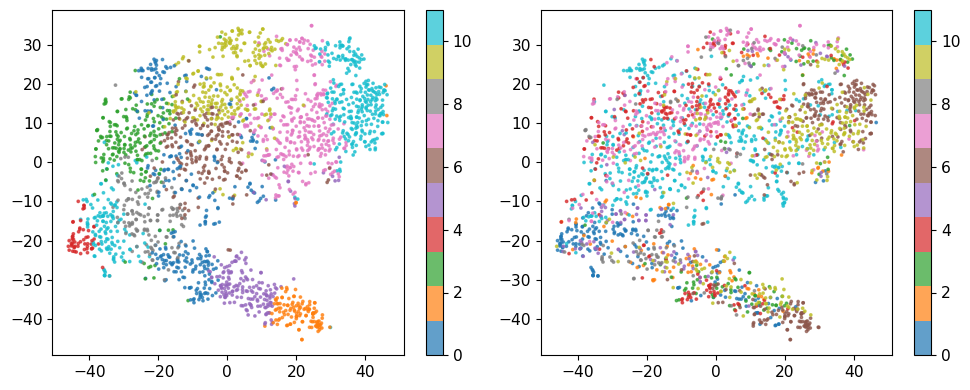

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: PCA + KMeans | UMAP


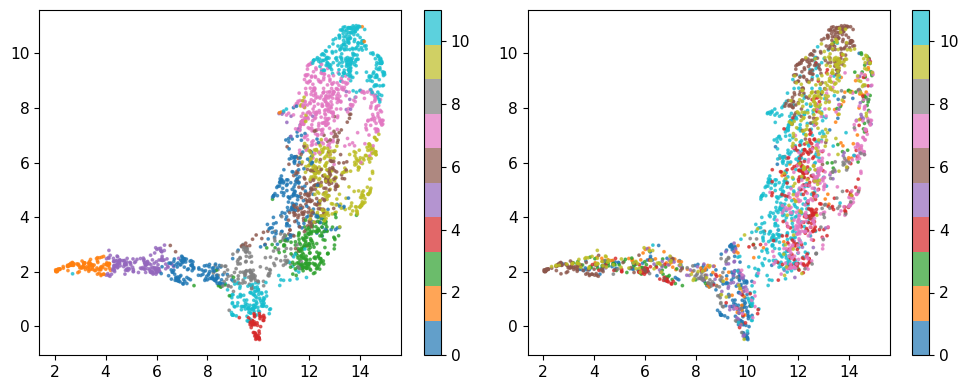


Showing: CVAE + KMeans | t-SNE


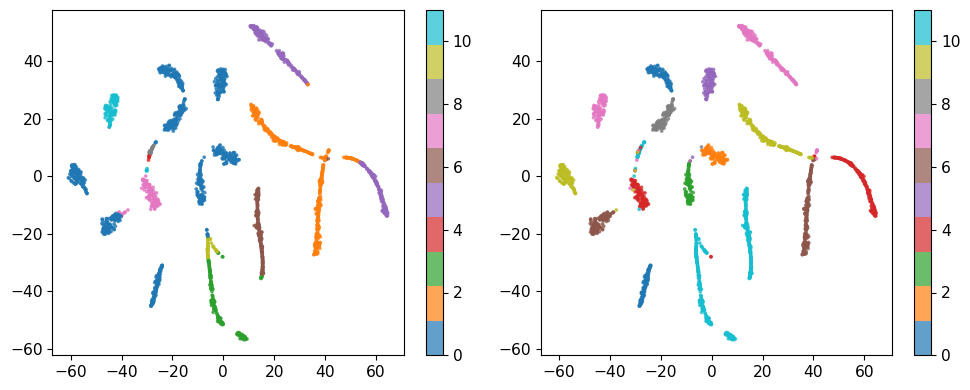

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: CVAE + KMeans | UMAP


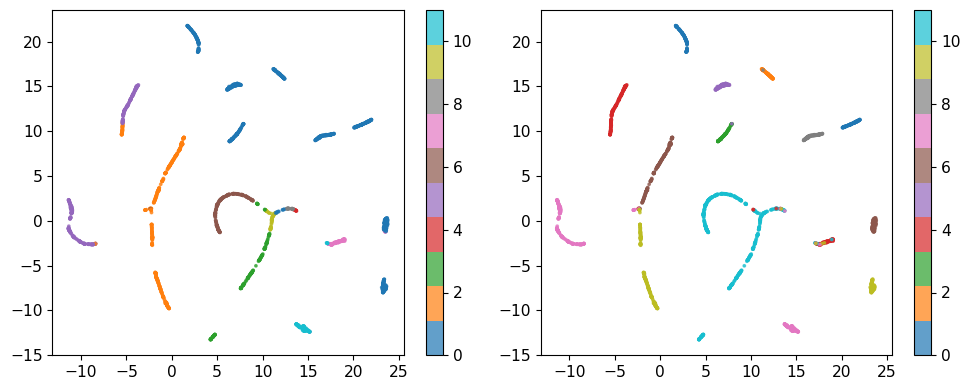


Showing: BetaVAE + KMeans | t-SNE


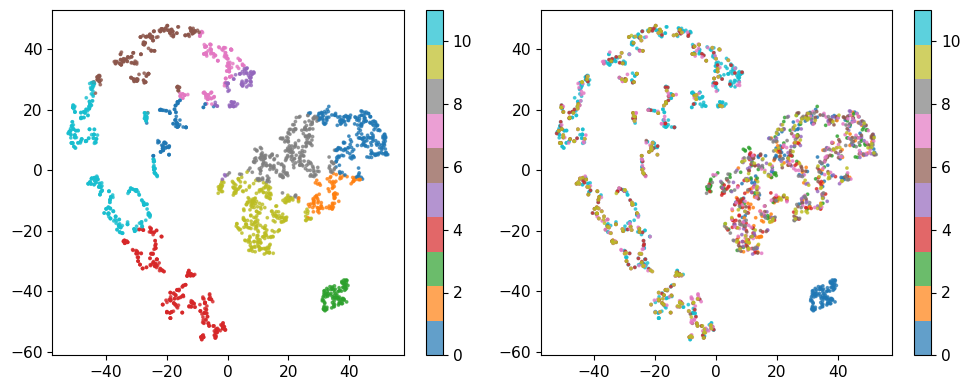

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: BetaVAE + KMeans | UMAP


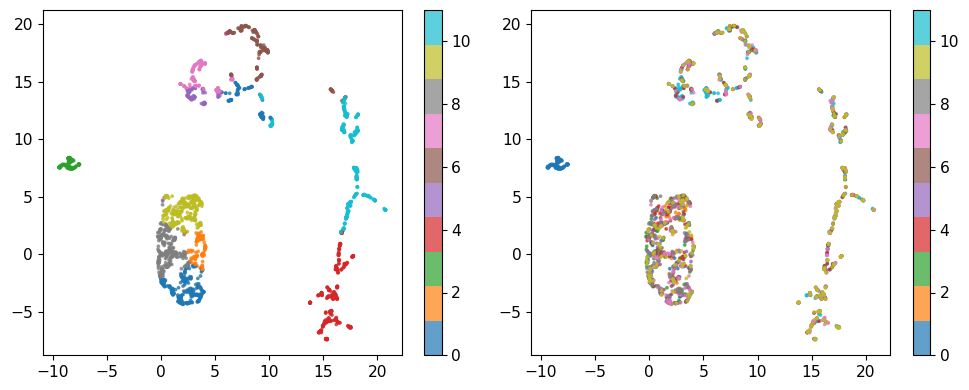


Showing: AE + KMeans | t-SNE


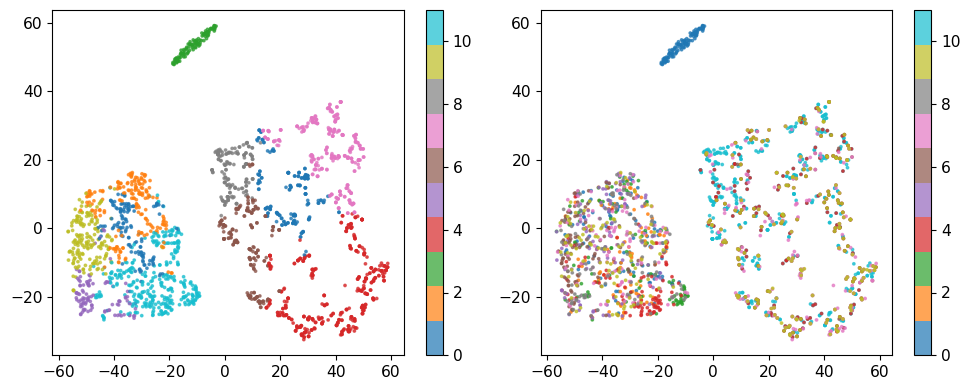

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Showing: AE + KMeans | UMAP


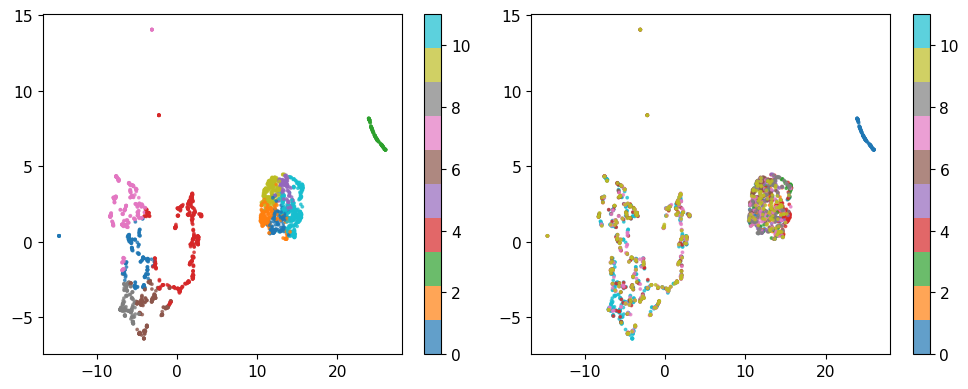


Done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, calinski_harabasz_score,
    normalized_mutual_info_score
)
from sklearn.manifold import TSNE

# UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

import tensorflow as tf
import tensorflow.keras as keras

# ====================== LOAD MODELS ======================
print("Loading models...")

cvae_encoder = keras.models.load_model(
    f"{BASE_DIR}/models/hard/encoder_CVAE_epoch_019.keras",
    custom_objects={'Sampling': Sampling, 'L2NormalizeLayer': L2NormalizeLayer}
)

beta_vae_encoder = keras.models.load_model(
    f"encoder_BetaVAE_epoch_017.keras",
    custom_objects={'Sampling': Sampling, 'L2NormalizeLayer': L2NormalizeLayer, 'LogVarClip': LogVarClip}
)

ae_encoder = keras.models.load_model(
    f"{BASE_DIR}/models/hard/encoder_AE_epoch_012.keras",
    custom_objects={'L2NormalizeLayer': L2NormalizeLayer}
)

print("Models loaded.")

# ====================== EXTRACT LATENTS ======================
print("Extracting latents...")

z_mean_cvae, _, _ = cvae_encoder.predict([Xz, lyrics_all, genres_all_encoded], batch_size=BATCH_SIZE)
z_mean_beta, _, _ = beta_vae_encoder.predict([Xz, lyrics_all], batch_size=BATCH_SIZE)
z_latent_ae = ae_encoder.predict([Xz, lyrics_all], batch_size=BATCH_SIZE)

print("Latents ready.")

# ====================== PCA BASELINE ======================
spec_flat = Xz.reshape(Xz.shape[0], -1)
X_hybrid = np.concatenate([spec_flat, lyrics_all], axis=1)

pca = PCA(n_components=32, random_state=42)
X_pca = pca.fit_transform(X_hybrid)

# ====================== CLUSTERING ======================
def run_clustering(X):
    results = {}

    results["KMeans"] = KMeans(n_clusters=12, n_init=10, random_state=42).fit_predict(X)
    results["Agglomerative"] = AgglomerativeClustering(n_clusters=12).fit_predict(X)
    results["DBSCAN"] = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)

    return results

# ====================== METRICS ======================
def get_metrics(features, labels, name):
    if len(np.unique(labels)) < 2:
        return {
            "Method": name,
            "Silhouette": np.nan,
            "DB": np.nan,
            "CH": np.nan,
            "NMI": normalized_mutual_info_score(genres, labels),
            "ARI": adjusted_rand_score(genres, labels),
            "Purity": cluster_purity(genres, labels)
        }

    return {
        "Method": name,
        "Silhouette": silhouette_score(features, labels),
        "DB": davies_bouldin_score(features, labels),
        "CH": calinski_harabasz_score(features, labels),
        "NMI": normalized_mutual_info_score(genres, labels),
        "ARI": adjusted_rand_score(genres, labels),
        "Purity": cluster_purity(genres, labels)
    }

# ====================== EVALUATION ======================
results = []

methods = {
    "PCA": X_pca,
    "CVAE": z_mean_cvae,
    "BetaVAE": z_mean_beta,
    "AE": z_latent_ae
}

cluster_results = {}

for name, X in methods.items():
    cluster_outputs = run_clustering(X)
    cluster_results[name] = cluster_outputs

    for algo, labels in cluster_outputs.items():
        results.append(get_metrics(X, labels, f"{name} + {algo}"))

df = pd.DataFrame(results)
print("\n=== FINAL RESULTS ===")
print(df)
df.to_csv(f"{BASE_DIR}/final_results.csv", index=False)

# ====================== CLEAN PLOTTING ======================
def plot_embedding(X, labels, true_genres, title, method="t-SNE"):
    if method == "t-SNE":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)

    X_emb = reducer.fit_transform(X)

    POINT_SIZE = 3   # 🔥 small clean dots
    FONT_SIZE = 14

    print(f"\nShowing: {title} | {method}")

    plt.figure(figsize=(10, 4))

    # Predicted
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=labels, cmap='tab10',
        s=POINT_SIZE, alpha=0.7
    )
    cbar = plt.colorbar(scatter)
    cbar.ax.tick_params(labelsize=FONT_SIZE * 0.8)
    plt.xticks(fontsize=FONT_SIZE * 0.8)
    plt.yticks(fontsize=FONT_SIZE * 0.8)

    # True
    plt.subplot(1, 2, 2)
    y_true, _ = pd.factorize(true_genres)

    scatter2 = plt.scatter(
        X_emb[:, 0], X_emb[:, 1],
        c=y_true, cmap='tab10',
        s=POINT_SIZE, alpha=0.7
    )
    cbar2 = plt.colorbar(scatter2)
    cbar2.ax.tick_params(labelsize=FONT_SIZE * 0.8)

    plt.xticks(fontsize=FONT_SIZE * 0.8)
    plt.yticks(fontsize=FONT_SIZE * 0.8)

    plt.tight_layout()
    plt.show()

# ====================== VISUALIZE ======================
print("\nGenerating plots...")

for name, X in methods.items():
    # Only visualize KMeans results
    algo = "KMeans"
    labels = cluster_results[name][algo]

    plot_embedding(X, labels, genres, f"{name} + {algo}", method="t-SNE")

    if UMAP_AVAILABLE:
        plot_embedding(X, labels, genres, f"{name} + {algo}", method="UMAP")

print("\nDone.")

Loading CVAE models...
CVAE models loaded successfully.
Extracting latent representations for diversity sampling...
Selected genres: [np.str_('reggae'), np.str_('classical'), np.str_('adhunik'), np.str_('jazz'), np.str_('folk')]
Selected 5 diverse samples for reconstruction (prioritizing: reggae, classical, adhunik, jazz, folk).
Performing CVAE encoding and decoding...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
Reconstruction complete.


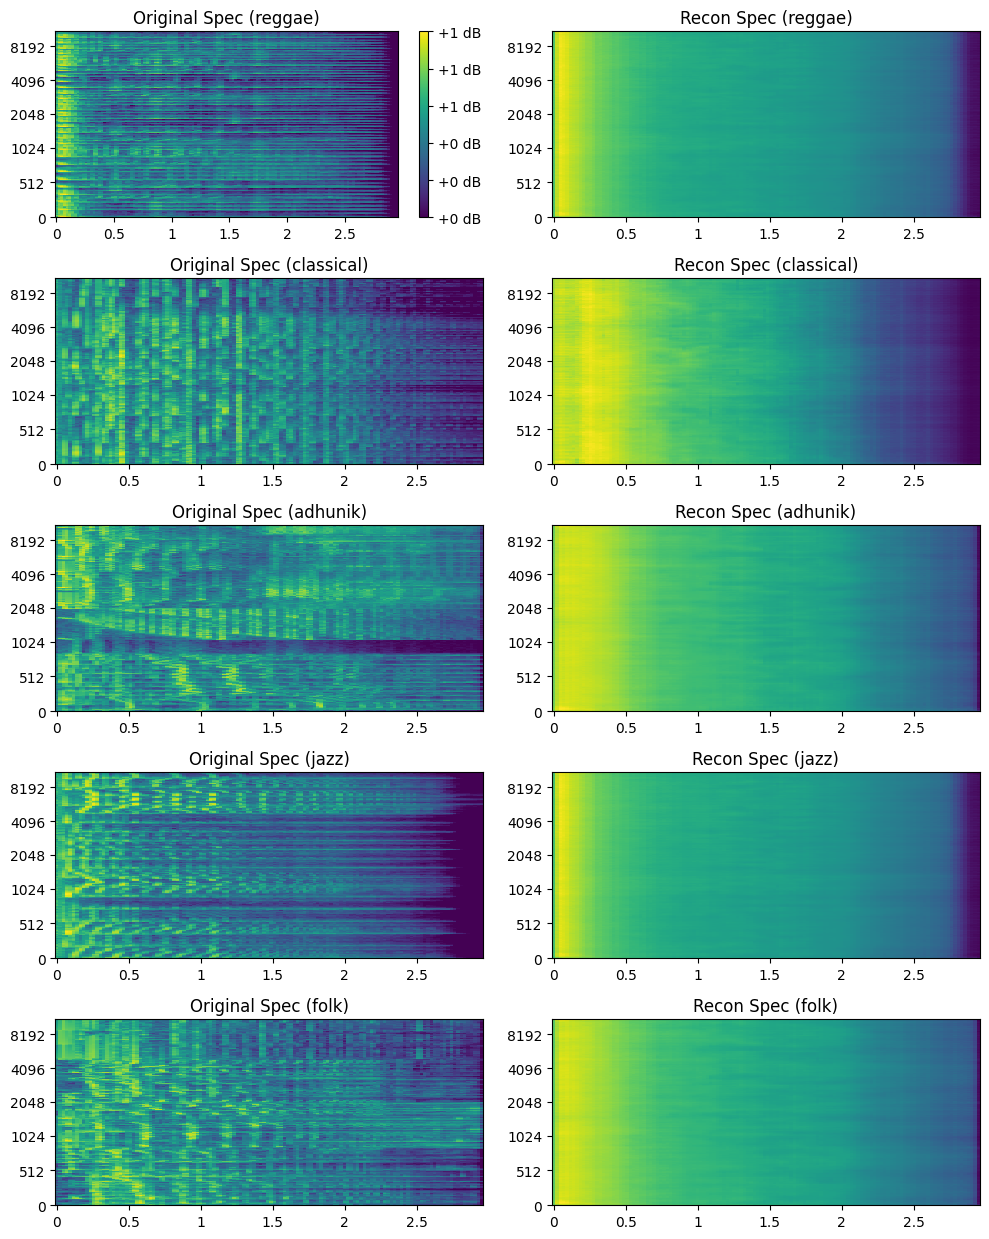

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
import tensorflow.keras as keras
import os
from sklearn.cluster import KMeans

custom_objects_cvae = {
    'Sampling': Sampling,
    'L2NormalizeLayer': L2NormalizeLayer
}

print("Loading CVAE models...")
try:
    cvae_encoder = keras.models.load_model(
        f"{BASE_DIR}/models/hard/encoder_CVAE_epoch_019.keras",
        custom_objects=custom_objects_cvae
    )
    cvae_decoder = keras.models.load_model(
        f"{BASE_DIR}/models/hard/decoder_CVAE_epoch_019.keras",
        custom_objects=custom_objects_cvae
    )
    print("CVAE models loaded successfully.")
except Exception as e:
    print(f"Error loading CVAE models: {e}")
    print("Please ensure the models are saved at the specified paths and the custom objects are correctly defined.")
    exit()

num_samples_to_reconstruct = 5
specified_genres = ['reggae', 'classical', 'adhunik', 'jazz', 'folk']

print("Extracting latent representations for diversity sampling...")
mu_all, _, _ = cvae_encoder.predict([Xz, lyrics_all, genres_all_encoded], batch_size=BATCH_SIZE, verbose=0);

selected_indices = []
selected_genres_set = set()

for genre_name in specified_genres:
    if len(selected_indices) >= num_samples_to_reconstruct:
        break

    if genre_name not in selected_genres_set:
        potential_genre_indices = np.where(genres == genre_name)[0]
        potential_genre_indices = [idx for idx in potential_genre_indices if idx not in selected_indices]

        if len(potential_genre_indices) > 0:
            chosen_index = np.random.choice(potential_genre_indices)
            selected_indices.append(chosen_index)
            selected_genres_set.add(genre_name)

remaining_samples_count = num_samples_to_reconstruct - len(selected_indices);

if remaining_samples_count > 0:
    available_indices_for_diversity = []
    for i in range(len(Xz)):
        if i not in selected_indices and genres[i] not in selected_genres_set:
            available_indices_for_diversity.append(i)
    available_indices_for_diversity = np.array(available_indices_for_diversity)

    if len(available_indices_for_diversity) > 0:
        unique_available_genres = np.unique(genres[available_indices_for_diversity])
        kmeans_n_clusters = min(remaining_samples_count, len(unique_available_genres))

        if kmeans_n_clusters > 0:
            kmeans_for_diversity = KMeans(n_clusters=kmeans_n_clusters, random_state=SEED, n_init=10)
            cluster_labels_available = kmeans_for_diversity.fit_predict(mu_all[available_indices_for_diversity])

            for cluster_id in np.unique(cluster_labels_available):
                if len(selected_indices) >= num_samples_to_reconstruct:
                    break

                cluster_members_global_indices = available_indices_for_diversity[np.where(cluster_labels_available == cluster_id)[0]]

                np.random.shuffle(cluster_members_global_indices)

                chosen_index_from_cluster = -1
                for idx in cluster_members_global_indices:
                    if genres[idx] not in selected_genres_set:
                        chosen_index_from_cluster = idx
                        break

                if chosen_index_from_cluster != -1:
                    selected_indices.append(chosen_index_from_cluster)
                    selected_genres_set.add(genres[chosen_index_from_cluster])

while len(selected_indices) < num_samples_to_reconstruct:
    unpicked_indices_with_unique_genres = []
    for i in range(len(Xz)):
        if i not in selected_indices and genres[i] not in selected_genres_set:
            unpicked_indices_with_unique_genres.append(i)

    if len(unpicked_indices_with_unique_genres) > 0:
        new_index = np.random.choice(unpicked_indices_with_unique_genres)
        selected_indices.append(new_index)
        selected_genres_set.add(genres[new_index])
    else:
        all_non_selected_indices = [i for i in range(len(Xz)) if i not in selected_indices]
        if len(all_non_selected_indices) > 0:
            new_index = np.random.choice(all_non_selected_indices)
            selected_indices.append(new_index)
            selected_genres_set.add(genres[new_index])
        else:
            print("Warning: Could not find enough unique samples without repeating indices.")
            break

selected_indices = selected_indices[:num_samples_to_reconstruct]

final_genres = [genres[i] for i in selected_indices]
print(f"Selected genres: {final_genres}")
if len(final_genres) != len(set(final_genres)):
    print("Warning: Duplicate genres found among selected samples despite efforts to avoid them.")

print(f"Selected {len(selected_indices)} diverse samples for reconstruction (prioritizing: {', '.join(specified_genres)}).")

original_specs = Xz[selected_indices]
original_lyrics = lyrics_all[selected_indices]
original_genres_encoded = genres_all_encoded[selected_indices]
original_genres_labels = genres[selected_indices]

print("Performing CVAE encoding and decoding...")
_, _, z_latent = cvae_encoder.predict([original_specs, original_lyrics, original_genres_encoded])

reconstructed_specs, reconstructed_lyrics = cvae_decoder.predict([z_latent, original_genres_encoded])
print("Reconstruction complete.")

plt.figure(figsize=(10, num_samples_to_reconstruct * 2.5))

for i in range(num_samples_to_reconstruct):
    genre_label = original_genres_labels[i]

    ax1 = plt.subplot(num_samples_to_reconstruct, 2, i*2 + 1)
    img1 = librosa.display.specshow(original_specs[i].squeeze().T, sr=22050, x_axis='time', y_axis='mel', cmap='viridis', ax=ax1);
    if i == 0:
        plt.colorbar(img1, format='%+2.0f dB', ax=ax1);
    plt.title(f'Original Spec ({genre_label})')
    plt.xlabel('')
    plt.ylabel('')

    ax2 = plt.subplot(num_samples_to_reconstruct, 2, i*2 + 2)
    img2 = librosa.display.specshow(reconstructed_specs[i].squeeze().T, sr=22050, x_axis='time', y_axis='mel', cmap='viridis', ax=ax2);
    plt.title(f'Recon Spec ({genre_label})')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()